# Building AI Agents with LLMs, RAG, and Knowledge Graphs

#PART1: 집합의 시대
## How to represent text for AI

In [ ]:
!pip install numpy time tqdm nltk gensim adjustText sklearn
!pip install gensim

ERROR: Could not find a version that satisfies the requirement time (from versions: none)
ERROR: No matching distribution found for time
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.0 MB/s eta 0:00:00


코랩 실행 시 오류 나는 라이브러리는 해당 셀 상단에서 설치

In [ ]:
!pip install adjustText

## **🚀 NLP 발전 과정**

아래는 텍스트 데이터가 인공지능이 이해할 수 있는 숫자로 변환되는 단계별 진화 과정입니다.

1. **Text**: 원문 데이터
2. **Tokenization**: 단어 단위 분리
####3. **One-Hot Encoding**: 단어 존재 여부 표시 **(현재 단계)**
4. **Embedding**: 단어의 의미 파악 (Word2Vec, GloVe)
5. **Transformer / LLM**: 문맥과 관계 파악 (BERT, GPT)

---

## **📋 단계별 핵심 개념 정리**

### **1. 토큰화 (Tokenization)**
* **정의:** 문장을 분석의 최소 단위인 '단어'로 분리하는 과정입니다.
* **현재 방식:** `split()` 함수를 이용한 **공백 기준 토큰화**를 사용 중입니다.

### **2. 어휘 집합 (Vocabulary)**
* **정의:** 전체 데이터에 등장한 **중복 없는 고유 단어들의 목록**입니다.
* **중요성:** 이 집합의 크기가 곧 **One-Hot 벡터의 차원(길이)**이 됩니다.

### **3. 원-핫 인코딩 (One-Hot Encoding)**
* **방식:** 단어 하나를 어휘 집합 크기만한 배열로 만듭니다.
* **특징:** 자기 자신의 위치만 **1**, 나머지는 모두 **0**으로 표시합니다.
* **한계:** 단어의 **의미나 관계**는 담지 못하고, 단순히 **존재 여부**만 나타냅니다.

---

## **📊 단어 표현 방식 비교**

| 구분 | One-Hot Encoding | Embedding (Word2Vec) |
| :--- | :--- | :--- |
| **주요 특징** | 해당 위치만 **1**, 나머지 **0** | 숫자로 채워진 **밀집 벡터** |
| **의미 파악** | **불가능** (단순 존재 표시) | **가능** (유사 단어끼리 가깝게 위치) |
| **데이터 크기** | 단어 수가 많을수록 벡터가 매우 커짐 | 일정한 크기의 차원 유지 (예: 100) |
| **현재 위치** | **NLP의 가장 기초 단계** | **의미론적 분석의 시작** |

---

In [2]:
import numpy as np

In [5]:
#전체코드: One Hot Encoding

def one_hot_encoding(sentence):
    words = sentence.lower().split()
    vocabulary = sorted(set(words))
    word_to_index = {word: i for i, word in enumerate(vocabulary)}
    one_hot_matrix = np.zeros((len(words), len(vocabulary)), dtype=int)
    for i, word in enumerate(words):
        one_hot_matrix[i, word_to_index[word]] = 1

    return one_hot_matrix, vocabulary

# Example of usage
sentence = "Should we go to a pizzeria or do you a prefer a restaurant?"
one_hot_matrix, vocabulary = one_hot_encoding(sentence)
print("Vocabulary:", vocabulary)
print("One-Hot Encoding Matrix:\n", one_hot_matrix)

Vocabulary: ['a', 'do', 'go', 'or', 'pizzeria', 'prefer', 'restaurant?', 'should', 'to', 'we', 'you']
One-Hot Encoding Matrix:
 [[0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0]]


Vocabulary 행렬 크기: 1 x 11

Vocabulary 인덱스:
a(0), do(1), go(2), or(3), pizzeria(4), prefer(5), restaurant?(6), should(7), to(8), we(9), you(10)

행렬의 의미:
행렬의 각 줄(Row)은 문장에 등장하는 단어의 순서를 나타내며, 해당 단어에 해당하는 인덱스 위치만 1로 표시하고 나머지는 모두 0으로 채웁니다.

In [ ]:
#연습: enumerate(), np.zeros
sentence = "Should we go to a pizzeria or do you prefer a restaurant?"
words = sentence.lower().split()
vocabulary = sorted(set(words))
word_to_index = {word: i for i, word in enumerate(vocabulary)}
##vocabulary를 enumerate(번호붙이기)하고 i,word를 꺼내서 word:i로 짝 지어라
one_hot_matrix = np.zeros((len(words), len(vocabulary)), dtype=int)
##np.zeros(a,b,c)는 a행 b열인 c타입의 행렬. 행은 시간순서, 열은 어휘목록이 된다.
for i, word in enumerate(words):
        one_hot_matrix[i, word_to_index[word]] = 1
#words를 풀어서 번호 매기면 word가 되고 그걸 i 순서로 정한다.
#그 다음 word가 word_to_index에서 몇 번째인지 찾아서 one_hot_matrix의 i번째로 이동한다.
#그리고 그 칸에는 1을 쓴다.

In [ ]:
#연습: 결과
print(words)
print(vocabulary)
print(word_to_index)
print(one_hot_matrix)

['should', 'we', 'go', 'to', 'a', 'pizzeria', 'or', 'do', 'you', 'prefer', 'a', 'restaurant?']
['a', 'do', 'go', 'or', 'pizzeria', 'prefer', 'restaurant?', 'should', 'to', 'we', 'you']
{'a': 0, 'do': 1, 'go': 2, 'or': 3, 'pizzeria': 4, 'prefer': 5, 'restaurant?': 6, 'should': 7, 'to': 8, 'we': 9, 'you': 10}
[[0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0]]


In [ ]:
#연습: enumerate()
fruits = ["apple", "banana", "cherry"]
for i, fruit in enumerate(fruits):
    print(i, fruit)

0 apple
1 banana
2 cherry


In [ ]:
#연습: enumerate(), for+in
# [ 결과(딕셔너리) / 꺼내기(i, fruit) / 기계(enumerate) ]
fruit_to_index = {fruit: i for i, fruit in enumerate(fruits)}
print(fruit_to_index)

{'apple': 0, 'banana': 1, 'cherry': 2}


## **🐍 NLP 핵심 파이썬 문법 3대장**

이 세 가지 문법은 "글자를 숫자로 바꾸는 컨베이어 벨트"의 부품들입니다.

### **1. 리스트 컴프리헨션: "보따리 풀기"**
**[작업]** 여러 겹 쌓인 상자를 한 번에 까서 알맹이만 일렬로 세우기
* **코드:** `[word for sublist in sentences for word in sublist]`
* **핵심 원칙:** 1.  가장 큰 보따리(`sentences`)를 먼저 연다.
    2.  그 안의 작은 봉지(`sublist`)를 꺼낸다.
    3.  최종 알맹이(`word`)만 **맨 앞**으로 보낸다.
* **결과:** `[[안녕, 하세요], [반가워요]]` → `[안녕, 하세요, 반가워요]` (2차원 → 1차원 평탄화)
---
### **2. enumerate: "번호표 발행기"**
**[작업]** 알맹이만 꺼내지 말고, 0번부터 순서대로 번호표 붙이기
* **코드:** `for i, word in enumerate(words):`
* **핵심 원칙:** 그냥 꺼내면 내용(`word`)만 나오지만, `enumerate`를 쓰면 **순서(`i`)**와 **내용**이 세트로 튀어나옵니다.
* **비유:** 마트 계산대에서 상품을 하나씩 찍으며 순번을 매기는 것과 같습니다.
---
### **3. 딕셔너리 컴프리헨션: "단어-번호부 완성"**
**[작업]** 단어를 넣으면 번호가 튀어나오는 **'전화번호부'** 만들기
* **코드:** `{word: i for i, word in enumerate(vocabulary)}`
* **핵심 원칙:** `for`문으로 번호와 단어를 꺼낸 뒤, `{키(단어): 값(번호)}` 형태로 묶어 영구 저장합니다.
* **결과:** `{'Apple': 0, 'Banana': 1, ...}` (글자를 컴퓨터용 주소로 매핑)

---

## **💡 데이터 변환 흐름 (Data Pipeline)**

이 문법들이 합쳐져서 원문 텍스트가 숫자로 변하는 과정입니다.



| 단계 | 사용하는 문법 | 결과물 예시 |
| :--- | :--- | :--- |
| **1. 펼치기** | **리스트 컴프리헨션** | `['나', '학교', '가다', '나', '밥', '먹다']` |
| **2. 번호매기기** | **enumerate** | `(0, '나'), (1, '학교'), (2, '가다')...` |
| **3. 사전만들기** | **딕셔너리 컴프리헨션** | `{'나': 0, '학교': 1, '가다': 2, ...}` |

---

### **✨ 정리하자면**
1.  **컴프리헨션**으로 단어들을 탈탈 털어서 모으고,
2.  **enumerate**로 그 단어들에 번호를 매긴 다음,
3.  **딕셔너리**로 그 번호표를 저장해서 나중에 **숫자 판(Matrix)**에 도장을 찍는 것입니다.


In [ ]:
#연습: 이중 for문, enumerate, 딕셔너리 컴프리헨션

import numpy as np

# 1. 원본 데이터 (누가 무엇을 봤는지)
raw_data = [("철수", "어벤져스"), ("영희", "기생충"), ("철수", "인터스텔라")]

# 2. 고유 번호표 만들기
# set을 써서 중복을 제거한 뒤 번호를 매깁니다.
user_list = sorted(list(set([d[0] for d in raw_data]))) # ['영희', '철수']
#raw_data에서 d를 꺼낸다. for d: 그 d에 대해서 d[0]을 구한다. 그걸 중복 제거하고 리스트화한다.그다음 정렬한다.
movie_list = sorted(list(set([d[1] for d in raw_data]))) # ['기생충', '어벤져스', '인터스텔라']
#raw_data에서 d를 꺼내고, 그 d에 대해(for) d[1]을 구한다. 거기에 중복제거, 리스트화, 정렬한다.

user_to_idx = {name: i for i, name in enumerate(user_list)}
#user_list에 번호를 배긴 것에서 꺼낸, i, name에 대하여(for) name: name과 i 짝을 만들라.
movie_to_idx = {movie: i for i, movie in enumerate(movie_list)}
#movie_list에서 번호 매긴 i, movie에 대하여(for) movie:i 짝을 반환하라

# 3. 빈 행렬 만들기 (2명 x 3편)
matrix = np.zeros((len(user_to_idx), len(movie_to_idx)))

# 4. 이제 드디어 그 문법을 씁니다!
for user, movie in raw_data:
    u_idx = user_to_idx[user]    # '철수'는 몇 번? -> 1번
    m_idx = movie_to_idx[movie]  # '어벤져스'는 몇 번? -> 1번

    matrix[u_idx, m_idx] = 1     # (1, 1) 좌표에 1을 찍음

print("user_to_idx:", user_to_idx)
print("movie_to_idx:", movie_to_idx)
print("\n결과 행렬:\n", matrix)

user_to_idx: {'영희': 0, '철수': 1}
movie_to_idx: {'기생충': 0, '어벤져스': 1, '인터스텔라': 2}

결과 행렬:
 [[1. 0. 0.]
 [0. 1. 1.]]


## **🚀 NLP 발전 로드맵**

1.  **One-Hot Encoding**: 단어 하나하나를 0과 1로 표시
####2.  **Bag of Words (BoW)**: 문장 내 단어 출현 빈도를 카운트 **(현재 단계)**
3.  **TF-IDF**: 단어의 중요도(희소성)에 가중치 부여
4.  **Word Embedding**: 단어 간의 의미적 유사도 계산
5.  **Transformer**: 문맥과 관계를 완벽히 파악

---

## **🛍️ Bag of Words (단어 가방) 핵심 개념: 빈도**



### **1. 문서(Document) 단위의 표현**
* **One-hot**: "단어"를 벡터로 표현 (단어 하나당 벡터 하나)
* **BoW**: "문장(문서)" 전체를 하나의 벡터로 표현
* **원리**: 문장을 구성하는 각 단어가 "몇 번 등장했는가"를 숫자로 기록합니다.
* **결과**: 어휘 사전의 크기가 1,000개라면, 어떤 문장이든 1,000차원의 숫자 배열 하나로 요약됩니다.

### **2. BoW의 대전제: "순서는 상관없다"**
* **가방(Bag) 비유**: 가방 속에 단어들을 마구 집어넣은 것과 같습니다.
* **순서 무시**: 단어가 문장 앞쪽에 있는지 뒤쪽에 있는지는 중요하지 않습니다.
* **빈도(Frequency) 중심**: 오직 "어떤 단어가 얼마나 많이 들어있는가"가 그 문장의 성격을 결정한다고 가정합니다.

---

## **📊 이해를 돕는 예시 (Comparison)**

| 문장 | 나 | 학교 | 가다 | 밥 | 먹다 | 벡터 표현 (BoW) |
| :--- | :--: | :--: | :--: | :--: | :--: | :--- |
| **문장 A: 나 학교 가다** | 1 | 1 | 1 | 0 | 0 | `[1, 1, 1, 0, 0]` |
| **문장 B: 나 밥 먹다 나** | 2 | 0 | 0 | 1 | 1 | `[2, 0, 0, 1, 1]` |

---

### **⚠️ Bag of Words의 한계**
* **문맥 소실**: "내가 너를 사랑해"와 "너가 나를 사랑해"는 구성 단어와 빈도가 같으므로 **똑같은 벡터**로 취급됩니다. (의미 차이를 구분 못 함)
* **희소성 문제 (Sparsity)**: 사전 규모가 커질수록 벡터 대부분의 값이 0이 되어 메모리 낭비가 심해집니다.

In [ ]:
#전체코드: Bag of Words(BOW)

def bag_of_words(sentences):
    """
    Creates a bag-of-words representation of a list of documents.
    """
    tokenized_sentences = [sentence.lower().split() for sentence in sentences]
    flat_words = [word for sublist in tokenized_sentences for word in sublist]
    vocabulary = sorted(set(flat_words))
    word_to_index = {word: i for i, word in enumerate(vocabulary)}

    bow_matrix = np.zeros((len(sentences), len(vocabulary)), dtype=int)
    for i, sentence in enumerate(tokenized_sentences):
        for word in sentence:
            if word in word_to_index:
                bow_matrix[i, word_to_index[word]] += 1

    return vocabulary, bow_matrix

# Example of usage
corpus = ["This movie is awesome awesome", "I do not say is good, but neither awesome",
             "Awesome? Only a fool can say that"]
vocabulary, bow_matrix = bag_of_words(corpus)
print("Vocabulary:", vocabulary)
print("Bag of Words Matrix:\n", bow_matrix)

Vocabulary: ['a', 'awesome', 'awesome?', 'but', 'can', 'do', 'fool', 'good,', 'i', 'is', 'movie', 'neither', 'not', 'only', 'say', 'that', 'this']
Bag of Words Matrix:
 [[0 2 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1]
 [0 1 0 1 0 1 0 1 1 1 0 1 1 0 1 0 0]
 [1 0 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0]]


⚠️bag_of_words(corpus)는 이미 정의된 bag_of_words(sentences)에 의하여 corpus라는 데이터가 sentences로 읽힌다.

In [ ]:
#연습: 이중 for문

sentences=corpus
#그릇<-내용물

tokenized_sentences = [sentence.lower().split() for sentence in sentences]
flat_words = [word for sublist in tokenized_sentences for word in sublist]
##이중 for문: 중간-뒤-앞 순서로 읽 [ 택배(앞) / for 동 in 아파트(중간) / for 택배 in 동(뒤) ]
##tokenized_sentences에서 sublist를 꺼내고,그 sublist에서 word를 꺼낸 다음,그 word들을 모아 flat_words라고 이름 붙였다!"
##tokenized_sentences는 3개의 문장 -> sublist는 각각의 문장 -> word는 각각의 단어로 풀어줌.
vocabulary = sorted(set(flat_words))
word_to_index = {word: i for i, word in enumerate(vocabulary)}

print(tokenized_sentences)
print(flat_words)
print(vocabulary)
print(word_to_index)

[['this', 'movie', 'is', 'awesome', 'awesome'], ['i', 'do', 'not', 'say', 'is', 'good,', 'but', 'neither', 'awesome'], ['awesome?', 'only', 'a', 'fool', 'can', 'say', 'that']]
['this', 'movie', 'is', 'awesome', 'awesome', 'i', 'do', 'not', 'say', 'is', 'good,', 'but', 'neither', 'awesome', 'awesome?', 'only', 'a', 'fool', 'can', 'say', 'that']
['a', 'awesome', 'awesome?', 'but', 'can', 'do', 'fool', 'good,', 'i', 'is', 'movie', 'neither', 'not', 'only', 'say', 'that', 'this']
{'a': 0, 'awesome': 1, 'awesome?': 2, 'but': 3, 'can': 4, 'do': 5, 'fool': 6, 'good,': 7, 'i': 8, 'is': 9, 'movie': 10, 'neither': 11, 'not': 12, 'only': 13, 'say': 14, 'that': 15, 'this': 16}


## **🚀 NLP 발전 로드맵**

1.  **One-Hot Encoding**: 단어 존재 여부 표시
2.  **Bag of Words (BoW)**: 단순 출현 빈도 카운트
####3.  **TF-IDF**: 단어의 **희소성**을 고려한 중요도 산출 **(현재 단계)**
4.  **Word Embedding**: 단어 간의 의미적 유사도 계산
5.  **Transformer**: 문맥과 관계를 완벽히 파악

---

## **📊 BoW vs TF-IDF 핵심 비교**

| 항목 | Bag of Words (BoW) | TF-IDF |
| :--- | :--- | :--- |
| **값의 의미** | 단순 등장 횟수 (Count) | 단어의 상대적 **중요도** (Weight) |
| **흔한 단어** | **과대평가** (자주 나오면 장땡) | **자동 억제** (흔하면 점수 깎임) |
| **문서 구분력** | 낮음 (특징 잡기 어려움) | **높음** (핵심 키워드 추출 유리) |
| **전통 ML** | 가능 (기초 모델용) | **매우 적합** (분류 성능 우수) |

---

## **🧮 TF-IDF의 원리와 목적**



### **1. 왜 TF-IDF를 쓰는가? (BoW의 문제점 해결)**
* **흔한 단어의 함정**: 'is', 'the', 'a' 같은 기능어나 모든 문서에 등장하는 흔한 단어가 빈도수가 높다는 이유로 중요하게 취급되는 것을 방지합니다.
* **차별화된 가중치**: 모든 단어를 동일하게 취급하지 않고, **해당 문서만을 대표할 수 있는 단어**에 힘을 실어줍니다.

### **2. 두 가지 핵심 기준**
* **TF (Term Frequency)**: 특정 문서 안에서 자주 등장할수록 중요도가 올라갑니다.
* **IDF (Inverse Document Frequency)**: 여러 문서에 널리 등장할수록 "흔한 단어"로 간주하여 중요도를 낮춥니다.
  * *즉, 우리 문서에는 자주 나오는데, 다른 문서에는 별로 안 나오는 단어가 진짜 주인공입니다.*

---

## **⚠️ 반드시 기억할 유의사항**

> **"TF-IDF도 결국 BoW의 확장판이다!"**

* **순서 무시**: 단어가 나타나는 순서는 여전히 고려하지 않습니다.
* **문맥 이해 불가**: "사과가 맛없다"와 "사과가 맛있다"의 구조적 차이를 읽지 못합니다.
* **의미 유사도 없음**: '왕'과 '임금'이 비슷한 뜻이라는 것을 숫자로 표현하지 못합니다. (이건 다음 단계인 **Embedding**에서 해결합니다!)

In [ ]:
def compute_tf(sentences):
    """Compute the term frequency matrix for a list of sentences."""
    vocabulary = sorted(set(word for sentence in sentences for word in sentence.lower().split()))
    word_index = {word: i for i, word in enumerate(vocabulary)}
    tf = np.zeros((len(sentences), len(vocabulary)), dtype=np.float32)
    for i, sentence in enumerate(sentences):
        words = sentence.lower().split()
        word_count = len(words)
        for word in words:
            if word in word_index:
                tf[i, word_index[word]] += 1 / word_count
    return tf, vocabulary

def compute_idf(sentences, vocabulary):
    """Compute the inverse document frequency for a list of sentences."""
    num_documents = len(sentences)
    idf = np.zeros(len(vocabulary), dtype=np.float32)
    word_index = {word: i for i, word in enumerate(vocabulary)}
    for word in vocabulary:
        df = sum(1 for sentence in sentences if word in sentence.lower().split())
        idf[word_index[word]] = np.log(num_documents / (1 + df)) + 1  # Smoothing
    return idf

def tf_idf(sentences):
    """Generate a TF-IDF matrix for a list of sentences."""
    tf, vocabulary = compute_tf(sentences)
    idf = compute_idf(sentences, vocabulary)
    tf_idf_matrix = tf * idf
    return vocabulary, tf_idf_matrix

vocabulary, tf_idf_matrix = tf_idf(corpus)
print("Vocabulary:", vocabulary)
print("TF-IDF Matrix:\n", tf_idf_matrix)

Vocabulary: ['a', 'awesome', 'awesome?', 'but', 'can', 'do', 'fool', 'good,', 'i', 'is', 'movie', 'neither', 'not', 'only', 'say', 'that', 'this']
TF-IDF Matrix:
 [[0.         0.4        0.         0.         0.         0.
  0.         0.         0.         0.2        0.28109303 0.
  0.         0.         0.         0.         0.28109303]
 [0.         0.11111111 0.         0.1561628  0.         0.1561628
  0.         0.1561628  0.1561628  0.11111111 0.         0.1561628
  0.1561628  0.         0.11111111 0.         0.        ]
 [0.20078073 0.         0.20078073 0.         0.20078073 0.
  0.20078073 0.         0.         0.         0.         0.
  0.         0.20078073 0.14285715 0.20078073 0.        ]]


#PART2: 임베딩의 시대
##Embedding, application, and representation

In [10]:
!pip install gensim
!pip install adjustText

In [13]:
!pip install pandas

In [11]:
#라이브러리 코드
import numpy as np
import pandas as pd
import os
import re
import time
import nltk
from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from adjustText import adjust_text
from umap import UMAP
#nltk.download('punkt')

In [16]:
#파일 다운로드 코드
!wget https://github.com/SalvatoreRa/tutorial/blob/main/datasets/IMDB.zip?raw=true
!unzip IMDB.zip?raw=true
df=pd.read_csv("IMDB Dataset.csv")

--2026-04-06 12:09:38--  https://github.com/SalvatoreRa/tutorial/blob/main/datasets/IMDB.zip?raw=true
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/SalvatoreRa/tutorial/raw/refs/heads/main/datasets/IMDB.zip [following]
--2026-04-06 12:09:38--  https://github.com/SalvatoreRa/tutorial/raw/refs/heads/main/datasets/IMDB.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/SalvatoreRa/tutorial/refs/heads/main/datasets/IMDB.zip [following]
--2026-04-06 12:09:39--  https://raw.githubusercontent.com/SalvatoreRa/tutorial/refs/heads/main/datasets/IMDB.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.1

In [26]:
print(df.columns)
df.size

Index(['review', 'sentiment', 'reviews_processed', 'tokens'], dtype='object')


200000

## **📌 NLTK 토큰화 리소스: punkt, punkt_tab**

NLTK의 `punkt` 계열 리소스는 텍스트 내에서 '어디를 끊어야 할지'를 결정하기 위한 확률 모델 및 규칙 테이블 데이터입니다.

### **1. punkt**
* **핵심 역할:** 문장과 단어의 경계를 판단하는 **메인 토큰화 모델**
* **문맥 판단:** 마침표(`.`)가 문장의 끝인지, 단순 약어인지, 숫자의 일부인지를 문맥에 따라 결정
* **작동 예시:** `Dr.` 또는 `U.S.` 내부의 마침표는 문장 종결이 아니라고 판단
* **결과:** 문장 분리(`sent_tokenize`) 및 단어 토큰화의 기준점 역할을 수행

### **2. punkt_tab**
* **핵심 역할:** `punkt`가 판단 시 참조하는 **보조 규칙 데이터(Table)**
* **규칙 저장:** 약어 패턴, 숫자·소수점 패턴, 대문자 조합 등 고정된 규칙을 테이블 형태로 보유
* **작동 예시:** `3.14`에서 마침표는 소수점이므로 문장을 분리하지 않도록 명확한 규칙 제공
* **결과:** `punkt` 모델의 판단 결과가 틀리지 않도록 안정화 및 보완

---

### **🔗 관계 요약**
| 구분 | 역할 | 비유 |
| :--- | :--- | :--- |
| **punkt** | **판단 주체** | 문제를 푸는 **학생(모델)** |
| **punkt_tab** | **판단 근거** | 참고하는 **공식집(규칙 데이터)** |

> **⚠️ 주의:** 두 리소스가 **모두 로드되어 있어야** NLTK의 토큰화 기능이 에러 없이 정상적으로 동작합니다.



In [17]:
#자연어처리 라이브러리 및 리소스
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [18]:
#전체코드: 텍스트 전처리 및 토큰화
#re(정규표현식), nltk.word_tokenize 활용.
def preprocessing_reviews(reviews):

    """
    simple preprocessing: splitting on the space and remove word less than 1 chr
    """

    processed_reviews = []

    for review in tqdm(reviews):
        review = re.sub('<[^>]+>', '', review)
        processed = re.sub('[^a-zA-Z ]', '', review)
        words = processed.split()
        processed_reviews.append(' '.join([word.lower() for word in words if len(word) > 1]))
    return processed_reviews

df['reviews_processed'] = preprocessing_reviews(df['review'])
df['tokens'] = df['reviews_processed'].apply(nltk.word_tokenize)
df.head()

100%|██████████| 50000/50000 [00:03<00:00, 15579.05it/s]


,review,sentiment,reviews_processed,tokens
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,A wonderful little production. <br /><br />The...,positive,wonderful little production the filming techni...,"[wonderful, little, production, the, filming, ..."
2,I thought this was a wonderful way to spend ti...,positive,thought this was wonderful way to spend time o...,"[thought, this, was, wonderful, way, to, spend..."
3,Basically there's a family where a little boy ...,negative,basically theres family where little boy jake ...,"[basically, theres, family, where, little, boy..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is vi...,"[petter, matteis, love, in, the, time, of, mon..."


## **🚀 Word2Vec: 단어를 벡터 공간으로 임베딩하는 핵심 알고리즘**

---

### **1. 핵심 개념**
* **정의**: 단어를 고정된 차원의 실수 벡터(Embedding)로 변환하는 기법입니다.
* **학습 원리**: "비슷한 문맥에서 등장하는 단어들은 비슷한 의미를 가진다"는 **분포 가설**에 기반하여 의미를 학습합니다.
* **전통적 방식(TF-IDF 등)과의 차이**:
    * **의미 유사도**: 단순 빈도 계산이 아닌, 벡터 간 거리를 통해 단어 사이의 유사도를 측정합니다.
    * **벡터 연산**: 단어 간의 관계를 수학적으로 계산할 수 있습니다.
        > **연산 예시**: King - Man + Woman = Queen
---

### **2. Word2Vec의 두 가지 모델 설계**

| 구분 | **CBOW** (sg=0) | **Skip-gram** (sg=1) |
| :--- | :--- | :--- |
| **메커니즘** | 주변 단어로 **중심 단어** 예측 | 중심 단어로 **주변 단어** 예측 |
| **학습 속도** | 상대적으로 빠름 (Fast) | 상대적으로 느림 (Slow) |
| **강점** | 빈도 높은 단어 학습에 유리 | **희귀 단어** 및 세밀한 의미 포착에 유리 |
| **특징** | 문맥의 정보를 평균 내어 학습 | 단어 간의 관계를 더 정교하게 학습 |

---

### **3. 현재 코드의 설정**
* **사용 모델**: **Skip-gram** (`sg=1`)
* **선택 이유**: 중심 단어로부터 주변 맥락을 예측하는 방식을 통해, 데이터셋 내 희귀 단어의 의미와 단어 간의 복잡한 관계를 더욱 정확하게 반영하기 위함입니다.

In [19]:
#전체코드: Word2Vec(Skip-gram) 단어 임베딩 모델 학습 및 소요 시간 측정
start_time = time.time()
# embedding
model = Word2Vec(sentences=df['tokens'].tolist(),
                 sg=1,
                 vector_size=100,
                 window=5,
                 workers=4)

print(f'Time needed : {(time.time() - start_time) / 60:.2f} mins')

Time needed : 1.73 mins


## **🚀 Word2Vec & 계층적 군집화: 의미를 넘어 구조로**

---

## **📊 Word2Vec 모델 비교**

| 항목 | **CBOW** (sg=0) | **Skip-gram** (sg=1) |
| :--- | :--- | :--- |
| **예측 방향** | 주변 단어로 **중심 단어** 예측 | 중심 단어로 **주변 단어** 예측 |
| **학습 속도** | 상대적으로 빠름 (Fast) | 상대적으로 느림 (Slow) |
| **강점** | 빈도 높은 단어 학습에 유리 | **희귀 단어** 및 세밀한 의미 포착에 유리 |
| **현재 설정** | - | **선택됨 (데이터의 정교한 관계 파악)** |

---

## **🧠 Word2Vec 임베딩의 핵심**



### **1. 단어를 숫자의 공간으로**
* **밀집 벡터(Dense Vector)**: `model.wv[word]`는 단어를 100차원 이상의 실수 공간에 배치한 결과물입니다.
* **의미적 유사성**: 벡터 공간에서 거리가 가깝다는 것은 두 단어가 유사한 문맥에서 등장했음을 의미합니다.

### **2. 벡터 연산의 마법**
* 단순 빈도 계산(TF-IDF)과 달리 단어 간의 관계를 수학적으로 계산할 수 있습니다.
* **예시**: $vec(\text{King}) - vec(\text{Man}) + vec(\text{Woman}) \approx vec(\text{Queen})$

---

## **📉 계층적 군집화와 덴드로그램**



### **1. 군집 형성 원리**
* **Bottom-up 방식**: 개별 단어에서 시작해 가장 유사한 항목끼리 순차적으로 병합하여 하나의 트리(계층) 구조를 형성합니다.

### **2. Ward 연결법 (Ward Linkage)**
* **분산 최소화**: 군집을 합칠 때 **군집 내 분산(Variance) 증가를 최소화**하는 방향으로 병합을 진행하여 군집 크기를 균형 있게 유지합니다.
* **거리 기준**: 유클리드 거리(Euclidean distance)를 전제로 계산되므로, 시각화 시 Y축을 해당 지표로 설정하는 것이 정확합니다.

### **3. 덴드로그램 해석법**
* **세로축(Distance)**: 두 군집이 합쳐지는 지점의 높이가 낮을수록 두 단어(혹은 군집)는 매우 유사한 문맥을 공유합니다.
* **가로축**: 유사한 성격의 단어들이 물리적으로 가깝게 배치되어 계층 구조를 한눈에 보여줍니다.

---

## **⚠️ 분석 시 유의사항**

> **"Word2Vec은 의미를 찾고, 군집화는 그 관계를 구조화한다!"**

* **임베딩의 품질**: 학습 데이터가 부족하면 벡터 간 거리가 왜곡되어 군집화 결과도 신뢰하기 어려워집니다.
* **거리의 의미**: 덴드로그램 하단에서 일찍 묶이는 단어일수록 모델이 판단하기에 문맥상 서로 대체 가능한 **강력한 유의어**일 확률이 높습니다.

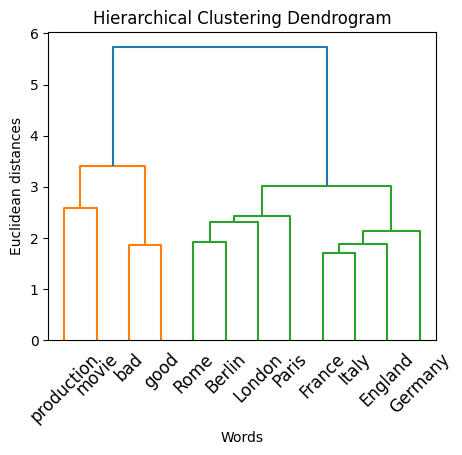

In [ ]:
#전체코드: Word2Vec 단어 벡터 계층적 클러스터링 및 시각화
#scipy.cluster.hierarchy(linkage, dendrogram) 활용

# Entire set of words in the model
all_words = list(model.wv.index_to_key)
all_vectors = np.array([model.wv[word] for word in all_words])

# Highlighted words and their vectors
highlight_words = ['Berlin', 'Paris', 'London','Rome', 'Italy',
                   'France', 'Germany', 'England', 'movie', 'production', 'good', 'bad']
highs = [w.lower() for w in highlight_words]
indices = [all_words.index(word) for word in highs if word in all_words]
highlight_vectors = np.array([all_vectors[index] for index in indices])

linked = linkage(highlight_vectors, 'ward')

plt.figure(figsize=(5, 4))
dendrogram(linked,
           orientation='top',
           labels=highlight_words,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Words')
plt.ylabel('Euclidean distances')
plt.xticks(rotation=45)
plt.savefig('word_dendrogram.jpg', format='jpeg', bbox_inches='tight')
plt.show()

In [ ]:
print(all_words)

['the', 'and', 'of', 'to', 'is', 'in', 'it', 'this', 'that', 'was', 'as', 'with', 'for', 'movie', 'but', 'film', 'on', 'not', 'you', 'are', 'his', 'have', 'be', 'he', 'one', 'its', 'at', 'all', 'by', 'an', 'they', 'who', 'from', 'like', 'so', 'or', 'just', 'her', 'about', 'has', 'out', 'if', 'some', 'what', 'there', 'good', 'more', 'very', 'when', 'even', 'up', 'no', 'my', 'would', 'can', 'she', 'time', 'only', 'which', 'really', 'their', 'see', 'were', 'story', 'had', 'me', 'than', 'much', 'we', 'well', 'been', 'get', 'will', 'into', 'other', 'great', 'do', 'bad', 'because', 'also', 'people', 'how', 'most', 'him', 'first', 'dont', 'movies', 'made', 'them', 'then', 'films', 'make', 'could', 'way', 'any', 'too', 'characters', 'after', 'think', 'watch', 'many', 'seen', 'being', 'two', 'character', 'never', 'love', 'acting', 'did', 'where', 'plot', 'little', 'best', 'know', 'show', 'life', 'ever', 'does', 'your', 'better', 'off', 'say', 'over', 'still', 'these', 'scene', 'end', 'man', 'sc

In [ ]:
print(all_vectors)

[[-0.1442526  -0.1101598   0.09411039 ...  0.04849748  0.05135971
   0.21565998]
 [-0.0248294   0.29829553  0.15689701 ... -0.18231325 -0.24761939
   0.14916125]
 [-0.26425835  0.07868462 -0.16700143 ... -0.07337397  0.13564053
  -0.16126782]
 ...
 [-0.05061933  0.03692715  0.19546147 ... -0.08045655 -0.08478662
  -0.0874602 ]
 [ 0.03690042  0.14638115  0.16110909 ... -0.14554144 -0.13796718
   0.08452457]
 [ 0.00854601  0.03386877  0.14245415 ... -0.15103266 -0.14661048
  -0.08990081]]


In [ ]:
print(highs)

['berlin', 'paris', 'london', 'rome', 'italy', 'france', 'germany', 'england', 'movie', 'production', 'good', 'bad']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from adjustText import adjust_text


## **🚀 Word2Vec & t-SNE: 고차원 의미 공간의 2차원 시각화**

---

## **🧠 t-SNE의 핵심 원리와 한계**

> **t-Distributed Stochastic Neighbor Embedding (t-SNE)**

* **직관적 정의**: **"이웃 관계를 확률 기반으로 정의하고, 이를 유지하도록 좌표에 박아 넣는다."** 📍
* **작동 방식**: 고차원에서 가까웠던 이웃들은 저차원(2D/3D)에서도 가깝게 유지하려고 노력합니다.
* **강점**: 복잡한 단어 임베딩의 **지역적 구조(Local Structure)**를 파악하는 데 매우 강력합니다.

### **⚠️ 반드시 기억할 유의사항 및 한계**

[Image illustrating t-SNE with local clusters but disjoint overall structure]

1. **전역 거리 해석 불가**: 시각화된 t-SNE 공간에서 **가까우면 유사한 것은 맞으나, 멀다고 해서 반드시 의미적으로 반대되거나 이질적이지는 않습니다.**
    * 논문 표현: *"local semantic neighborhoods are preserved"*
2. **랜덤성 (Stochastic)**: 확률 기반 알고리즘이므로 실행할 때마다 결과 좌표가 달라집니다. 따라서 **`random_state` 고정**은 비교 분석 시 필수입니다.

---

## **📊 시각화 파이프라인 디자인 (강조법)**



### **1. 데이터 준비 (Word Embedding)**
* `model.wv[word]`를 사용하여 고차원 벡터 데이터(예: 100차원)를 확보합니다.

### **2. t-SNE 차원 축소**
* `n_components=2`: 시각화를 위해 2차원으로 투영합니다.
* `random_state`: 일관된 결과를 위해 난수 시드를 고정합니다.

### **3. 시각화 전략 (Visual Hierarchy)**
* **배경 단어**: 분석 대상이 아닌 전체 단어들은 **연한 회색** 점으로 작게 찍어 전체적인 의미 공간의 윤곽만 보여줍니다.
* **선택 단어**: 강조하고자 하는 특정 단어들만 **진한 색상**으로 크게 찍습니다.

### **4. 라벨링 및 분석**
* 강조된 단어들에만 **라벨(Text)**을 붙여, 모델이 학습한 특정 어휘 집단의 **지역적 군집도(Semantic Neighborhood)**를 시각적으로 검증합니다.

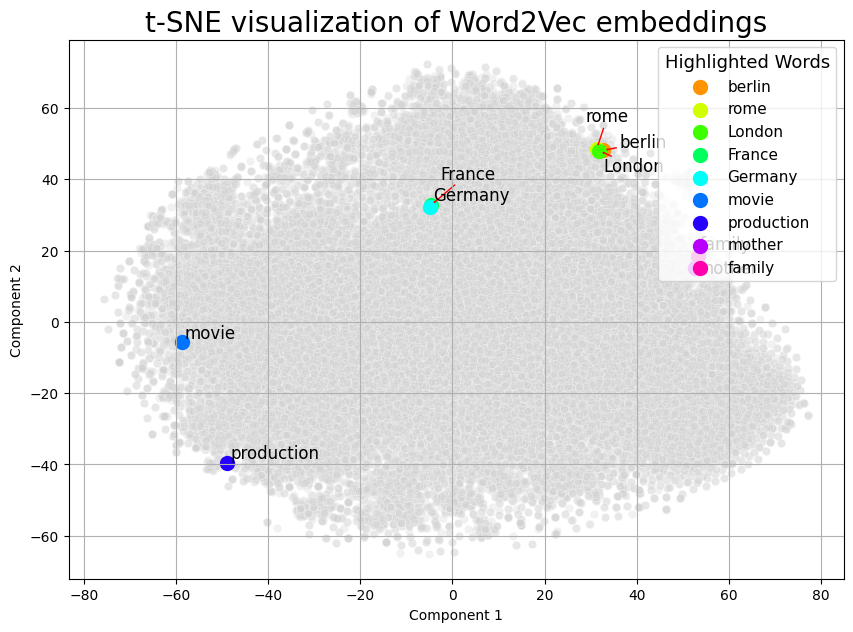

In [ ]:
# Apply t-SNE to the entire set of vectors
tsne = TSNE(n_components=2, random_state=0)
Y_tsne = tsne.fit_transform(all_vectors)

highlight_words = ['berlin', 'rome', 'London', 'France', 'Germany',
                    'movie', 'production', 'mother', 'family']

highs = [w.lower() for w in highlight_words]
indices = [all_words.index(word) for word in highs if word in all_words]
highlight_vectors = np.array([all_vectors[index] for index in indices])
Y_highlight = Y_tsne[indices]


plt.figure(figsize=(10, 7))


sns.scatterplot(x=Y_tsne[:, 0], y=Y_tsne[:, 1], color="lightgrey", alpha=0.3)

# Plot highlighted words
palette = sns.color_palette("hsv", len(highlight_words))
texts = []
for i, word in enumerate(highlight_words):
    plt.scatter(Y_highlight[i, 0], Y_highlight[i, 1], color=palette[i], s=100, label=word)
    # adjust text
    texts.append(plt.text(Y_highlight[i, 0], Y_highlight[i, 1], word, fontsize=12))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

plt.title('t-SNE visualization of Word2Vec embeddings', fontsize=20)
plt.xlabel('Component 1')
plt.ylabel('Component 2')


plt.grid(True)
plt.legend(title='Highlighted Words', title_fontsize='13', fontsize='11')
plt.savefig('word_tsne.jpg', format='jpeg')
plt.show()

정상적이고 잘 학습된 Word2Vec임.

✅ 지명 / 국가가 서로 가까움

✅ 산업 단어가 분리됨

✅ 가족/관계 단어가 또 다른 군집

✅ 서로 다른 의미 영역이 섞이지 않음
---
---

## **🛰️ UMAP: 고차원 단어 공간의 효율적 2차원 투영**

---

## **📊 핵심 기술: UMAP (Uniform Manifold Approximation and Projection)**



* **영역**: 차원 축소(Dimension Reduction) 및 고차원 데이터 시각화.
* **의미**: Word2Vec 등을 통해 생성된 수백 차원의 임베딩 벡터를 **데이터의 중요한 구조와 이웃 관계를 유지하며 2차원 평면으로 압축**하는 기술입니다. 📉
* **t-SNE와의 차이**:
    * **속도**: 데이터량이 많아질수록 t-SNE보다 압도적으로 빠릅니다. ⚡
    * **구조 보존**: 지역적 유사성뿐만 아니라 데이터의 **전역적인 구조(Global Structure)**를 더 잘 보존한다는 평가를 받습니다. 🌐

---

## **🔍 코드 상세 분석**

이 코드는 전체 단어 분포를 배경에 배치하고, 분석가가 지정한 특정 키워드만 하이라이트하여 가독성을 극대화합니다.

### **1. 차원 축소 실행 ⚙️**
```python
umap = UMAP(n_components=2, random_state=42)
Y_umap = umap.fit_transform(all_vectors)
```
* **`n_components=2`**: 복잡한 고차원 벡터를 시각화가 가능한 x, y 좌표로 변환합니다.
* **`random_state=42`**: 실행할 때마다 결과가 바뀌지 않도록 결과를 고정합니다. 📍

### **2. 배경 및 강조 단어 시각화 🎨**
```python
# 배경: 전체 단어를 연한 회색으로 시각화
sns.scatterplot(x=Y_umap[:, 0], y=Y_umap[:, 1], color="lightgrey", alpha=0.3)

# 강조: 특정 단어 좌표만 추출하여 색상 부여
Y_highlight = Y_umap[indices]
palette = sns.color_palette("hsv", len(highlight_words))
```
* **배경 처리**: 전체 데이터를 **연한 회색(`lightgrey`)**과 낮은 투명도(`alpha=0.3`)로 설정하여 데이터의 전체적인 윤곽(밀도)을 형성합니다. 🌫️
* **하이라이트**: 분석 대상인 `highlight_words`에만 고유한 색상을 입히고 크기를 키워 시선을 집중시킵니다.

### **3. 가독성 최적화 및 저장 📝**
```python
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))
plt.savefig('word_umap.jpg', format='jpeg')
```
* **`adjust_text`**: 단어 라벨이 서로 겹치지 않도록 자동으로 위치를 조정하고, 원래 좌표와 이름 사이를 빨간 화살표로 연결합니다. 📍➡️🔤
* **결과 저장**: 분석 결과를 고화질 이미지 파일로 출력합니다.

---

## **💡 기술적 분석 목적**

1.  **의미적 군집(Cluster) 확인**: 유사한 의미를 가진 단어(예: 음식점 관련 단어)들이 실제로 물리적으로 가깝게 모여 있는지 검증합니다. 🤝
2.  **데이터 탐색**: 방대한 단어 뭉치 속에서 내가 관심 있는 키워드가 어떤 맥락적 위치에 있는지 직관적으로 파악합니다. 🔎
3.  **모델 디버깅**: 전혀 상관없는 단어들이 한곳에 뭉쳐 있다면, 학습 데이터의 편향성이나 하이퍼파라미터 수정 필요성을 시사합니다. 🛠️

---

## **⚠️ 반드시 기억할 점**

> **"멀다고 해서 반드시 무관한 것은 아니지만, 가깝다면 확실히 유사하다!"**

* UMAP이 전역 구조를 잘 잡는다고 해도, 차원 축소 과정에서 정보 손실은 불가피합니다.
* 시각화 결과는 절대적인 수치가 아니라 **단어 간의 상대적인 관계**를 파악하는 용도로 활용해야 합니다. 🧐

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


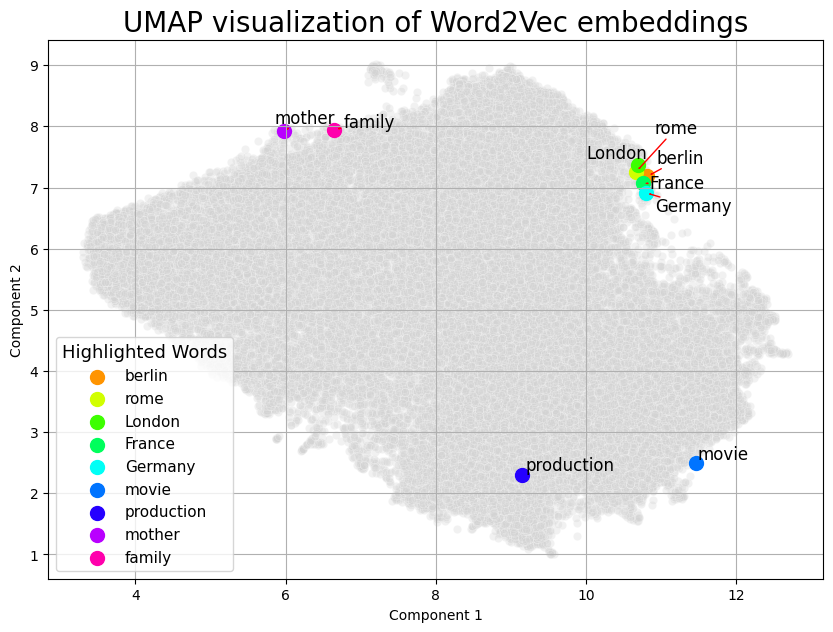

In [ ]:
# Apply UMAP to the entire set of vectors
umap = UMAP(n_components=2, random_state=42)
Y_umap = umap.fit_transform(all_vectors)

Y_highlight = Y_umap[indices]


plt.figure(figsize=(10, 7))
sns.scatterplot(x=Y_umap[:, 0], y=Y_umap[:, 1], color="lightgrey", alpha=0.3)

palette = sns.color_palette("hsv", len(highlight_words))
texts = []
for i, word in enumerate(highlight_words):
    plt.scatter(Y_highlight[i, 0], Y_highlight[i, 1], color=palette[i], s=100, label=word)

    texts.append(plt.text(Y_highlight[i, 0], Y_highlight[i, 1], word, fontsize=12))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

plt.title('UMAP visualization of Word2Vec embeddings', fontsize=20)
plt.xlabel('Component 1')
plt.ylabel('Component 2')


plt.grid(True)
plt.legend(title='Highlighted Words', title_fontsize='13', fontsize='11')
plt.savefig('word_umap.jpg', format='jpeg')
plt.show()

## **📐 코사인 유사도: 벡터 사이의 각도와 의미적 거리**

---

## **📊 핵심 기술: 코사인 유사도 (Cosine Similarity)**



* **영역**: 벡터 수학, 정보 검색(Information Retrieval), 추천 시스템.
* **의미**: 두 벡터가 가리키는 **방향이 얼마나 일치하는가**를 측정합니다. 벡터의 크기(화살표의 길이)보다는 두 벡터 사이의 **각도($\theta$)**에 집중하는 방식입니다.
* **값의 범위**:
    * **1**: 두 벡터의 방향이 완전히 일치 ($\theta = 0^\circ$)
    * **0**: 두 벡터가 직교함 ($\theta = 90^\circ$, 상관관계 없음)
    * **-1**: 두 벡터가 정반대 방향 ($\theta = 180^\circ$)

---

## **🔍 코드 상세 분석**

이 코드는 두 개의 2차원 벡터를 입력받아 그 사이의 각도를 계산하고, 이를 그래프로 시각화하는 과정을 담고 있습니다.

### **1. 수학적 계산 단계 🧮**
```python
dot_product = np.dot(v1, v2)             # 내적 계산
norm_v1 = np.linalg.norm(v1)             # 벡터 v1의 크기(길이)
norm_v2 = np.linalg.norm(v2)             # 벡터 v2의 크기(길이)
cosine_similarity = dot_product / (norm_v1 * norm_v2) # 코사인 공식
```
* 코사인 유사도 공식인 $$\cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|}$$를 코드로 구현한 것입니다.

### **2. 각도 산출 🧭**
```python
angle_radians = np.arccos(cosine_similarity) # 코사인 값을 라디안 각도로 변환
angle_degrees = np.degrees(angle_radians)    # 라디안을 도(degree)로 변환
```
* `arccos`(역코사인) 함수를 통해 유사도 수치를 실제 각도로 역계산하여 직관적인 이해를 돕습니다.

### **3. 시각화 핵심 (Quiver & Arc) 🎨**
* **`ax.quiver`**: 원점(0,0)에서 시작하는 화살표(벡터)를 그립니다. 🏹
* **`theta = np.linspace(...)`**: 두 화살표 사이에 부채꼴 모양의 호(Arc)를 그려 각도 $\theta$를 시각적으로 표시합니다.
* **`ax.annotate`**: 그래프 위에 수학 기호 $\theta$와 수치를 표시하여 가독성을 높입니다. 📝

---

## **💡 NLP에서의 실제 활용 의미**

자연어 처리(NLP) 분야에서 코사인 유사도가 표준처럼 쓰이는 이유는 명확합니다.

1.  **단어 유사도 비교**: '강아지' 벡터와 '개' 벡터의 코사인 유사도를 구하면 1에 가깝게 나타나며, 이는 두 단어가 문맥상 매우 비슷하게 쓰임을 수학적으로 증명합니다. 🐕
2.  **검색 및 추천 시스템**: 사용자의 검색 쿼리 벡터와 가장 유사한 각도를 가진 문서나 상품 벡터를 찾아 결과로 제시합니다. 🔎
3.  **크기 정규화(Normalization)에 강함**: 문서의 길이나 단어의 절대적 빈도(벡터의 길이)에 상관없이, 단어들이 사용된 **상대적인 비중(방향)**에 집중하기 때문에 텍스트 분석에 매우 유리합니다. ✅

---

## **📌 요약**

| 구분 | **UMAP (거시적)** | **Cosine Similarity (미시적)** |
| :--- | :--- | :--- |
| **관점** | 숲 전체 (수만 개의 단어 분포) 🌲 | 나무 두 그루 (두 단어 사이의 관계) 🌳 |
| **목적** | 데이터의 전체적인 군집 구조 파악 | 특정 개체 간의 정밀한 유사도 측정 |
| **비유** | 위성 지도로 도시 구역 확인 🗺️ | 자로 두 지점 사이의 각도 측정 📏 |

/tmp/ipykernel_11532/701560292.py:19: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(v1, v2) < 0:


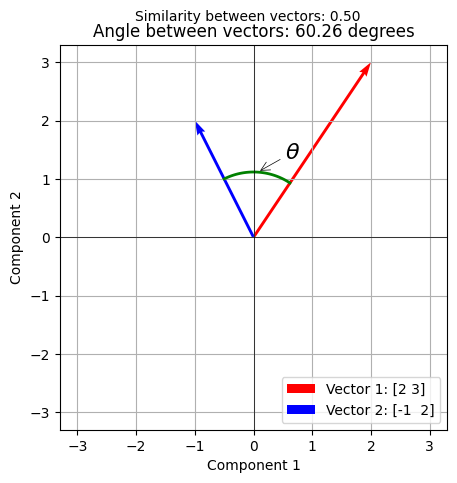

In [ ]:
def plot_vectors_and_angle(v1, v2):

    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    cosine_similarity = dot_product / (norm_v1 * norm_v2)
    angle_radians = np.arccos(cosine_similarity)
    angle_degrees = np.degrees(angle_radians)


    fig, ax = plt.subplots(figsize=(5, 5))


    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='r', label=f"Vector 1: {v1}")
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='b', label=f"Vector 2: {v2}")


    start_angle = np.arctan2(v1[1], v1[0])
    if np.cross(v1, v2) < 0:
        angle_radians = -angle_radians


    theta = np.linspace(start_angle, start_angle + angle_radians, 100)
    r = 0.5 * min(np.linalg.norm(v1), np.linalg.norm(v2))
    x = r * np.cos(theta)
    y = r * np.sin(theta)


    ax.plot(x, y, linestyle='-', color='green', lw=2)


    midpoint = (start_angle + angle_radians / 2)
    ax.annotate(r'$\theta$', xy=(r * np.cos(midpoint), r * np.sin(midpoint)), xytext=(20, 10),
                textcoords='offset points', fontsize=16, arrowprops=dict(arrowstyle='->', lw=0.5))


    max_range = np.max(np.abs(np.vstack([v1, v2, [x.max(), y.max()]]))) * 1.1  # 10% padding
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])


    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title(f'Angle between vectors: {angle_degrees:.2f} degrees')
    plt.suptitle(f'Similarity between vectors: {cosine_similarity:.2f}', fontsize=10, y=.95)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend(loc='lower right')
    plt.savefig('cosine_similarity.jpg', format='jpeg', bbox_inches='tight')
    plt.show()

    return cosine_similarity, angle_degrees

# Example usage
v1 = np.array([2, 3])
v2 = np.array([-1, 2])
cos_sim, angle = plot_vectors_and_angle(v1, v2)



### 1. 코드 상세 설명

이 코드는 두 개의 2차원 벡터를 입력받아 그 사이의 각도를 계산하고, 이를 그래프로 그려줍니다.

#### ① 수학적 계산 단계
```python
dot_product = np.dot(v1, v2)             # 내적 계산
norm_v1 = np.linalg.norm(v1)             # 벡터 v1의 크기(길이)
norm_v2 = np.linalg.norm(v2)             # 벡터 v2의 크기(길이)
cosine_similarity = dot_product / (norm_v1 * norm_v2) # 코사인 공식
```
* 코사인 유사도 공식인 $$\cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|}$$를 코드로 구현한 것입니다.

#### ② 각도 산출
```python
angle_radians = np.arccos(cosine_similarity) # 코사인 값을 라디안 각도로 변환
angle_degrees = np.degrees(angle_radians)    # 라디안을 우리가 아는 도(degree)로 변환
```
* `arccos`를 통해 유사도 수치를 각도로 역계산합니다.

#### ③ 시각화 핵심 (Quiver & Arc)
* **`ax.quiver`**: 원점(0,0)에서 시작하는 화살표(벡터)를 그립니다.
* **`theta = np.linspace(...)`**: 두 화살표 사이에 부채꼴 모양의 호(Arc)를 그려 각도 $\theta$를 시각적으로 표시합니다.
* **`ax.annotate(r'$\theta$', ...)`**: 그래프 위에 수학 기호 $\theta$와 화살표를 표시하여 가독성을 높입니다.

---

### 2. 이 기술의 실제 의미: NLP에서의 활용

자연어 처리에서 이 기술은 매우 중요하게 쓰입니다.

1.  **단어 유사도 비교:** '강아지' 벡터와 '개' 벡터의 코사인 유사도를 구하면 1에 가깝게 나오며, 이는 두 단어가 문맥상 비슷하게 쓰임을 의미합니다.
2.  **검색 시스템:** 사용자의 검색어 벡터와 가장 유사한 각도를 가진 문서 벡터를 찾아 결과로 보여줍니다.
3.  **정규화에 강함:** 코사인 유사도는 문서의 길이나 단어의 빈도(벡터의 길이)에 영향을 덜 받고, 단어들이 사용된 **상대적인 비중(방향)**에 집중하기 때문에 텍스트 분석에 유리합니다.

---

### 요약
* **첫 번째 코드(UMAP)**: 숲 전체(수만 개의 단어 분포)를 보는 기술.
* **두 번째 코드(Cosine Similarity)**: 나무 두 그루 사이의 거리(두 단어의 구체적인 유사도)를 재는 기술.
----

In [ ]:
word_1 = "good"
syn = "great"
ant = "bad"
most_sim =model.wv.most_similar("good")
print("Top 3 most simalr words to {} are :{}".format(word_1, most_sim[:3]))

synonyms_dist = model.wv.distance(word_1, syn)
antonyms_dist = model.wv.distance(word_1, ant)
print("Synonyms {}, {} have cosine distance: {}".format(word_1, syn, synonyms_dist))
print("Antonyms {}, {} have cosine distance: {}".format(word_1, ant, antonyms_dist))
a = 'king'
a_star = 'man'
b = 'woman'
b_star= model.wv.most_similar(positive=[a, b], negative=[a_star])
print("{} is to {} as {} is to: {} ".format(a, a_star, b, b_star[0][0]))

Top 3 most simalr words to good are :[('decent', 0.8021911978721619), ('great', 0.7807803750038147), ('bad', 0.7658742666244507)]
Synonyms good, great have cosine distance: 0.21921968460083008
Antonyms good, bad have cosine distance: 0.23412573337554932
king is to man as woman is to: queen 


### 1. 단어 유사도 및 거리 측정 (Similarity & Distance)

이 부분은 모델이 학습한 벡터 공간에서 단어들이 얼마나 가까이 있는지를 계산합니다.

* **`model.wv.most_similar("good")`**: "good"과 벡터 각도가 가장 가까운(코사인 유사도가 높은) 단어들을 찾아줍니다. 모델이 문맥을 잘 이해했다면 "nice", "excellent" 같은 단어가 상위권에 나옵니다.
* **`model.wv.distance(word_1, syn)`**: 두 단어 사이의 **코사인 거리(Cosine Distance)**를 구합니다.
    * **공식:** $Distance = 1 - Similarity$
    * 유사도가 1에 가까울수록 거리는 0에 수렴합니다. 즉, 유의어(Synonyms)인 "good"과 "great"의 거리는 반의어(Antonyms)인 "good"과 "bad"의 거리보다 짧아야 정상적으로 학습된 모델입니다.



---

### 2. 단어 산술 연산 (Word Analogy / Vector Arithmetic)

이 코드의 하이라이트이자 Word2Vec의 혁신성을 보여주는 기술입니다.

```python
b_star = model.wv.most_similar(positive=[a, b], negative=[a_star])
# 논리: King + Woman - Man = ?
```

* **영역:** 관계 추론(Relational Reasoning).
* **기술적 의미:** 단어의 의미를 '방향'과 '길이'를 가진 벡터로 치환했기 때문에 **더하기와 빼기**가 가능해집니다.
    * `King` 벡터에서 `Man` 벡터를 빼면 '남성성'이라는 속성이 제거되고 '왕권/지위'라는 추상적 개념만 남습니다.
    * 여기에 `Woman` 벡터를 더하면 '여성성'이 결합되어 결과적으로 **`Queen`**에 가장 가까운 벡터가 생성됩니다.
* **코드의 의미:** "King이 Man인 것과 마찬가지로, Woman에게 대응하는 단어는 무엇인가?"라는 질문에 대한 답을 찾는 과정입니다.



---

### 3. 전체 코드의 핵심 요약

| 기능 | 코드 메서드 | 기술적 목표 |
| :--- | :--- | :--- |
| **유사 단어 찾기** | `most_similar` | 특정 단어와 문맥적으로 유사한 이웃 탐색 |
| **거리 측정** | `distance` | 두 단어 사이의 수치적 이격도 확인 |
| **유추 연산** | `positive/negative` | 단어 간의 관계성(성별, 시제, 국가-수도 등) 파악 |

# RNN, LSTM, GRU, CNN for text

### 1단계: 통계 및 빈도 기반 (기호의 시대)
단어를 단순히 **'숫자'나 '횟수'**로만 취급하던 시기입니다.
* **원-핫 인코딩:** 단어 하나를 0과 1의 벡터로 표시 (단어 간 관계 알 수 없음).
* **BoW & TF-IDF:** 문장에 단어가 몇 번 나오는지, 얼마나 중요한지를 통계적으로 계산.


### 2단계: 분포 가설 및 임베딩 (의미의 시대)
단어를 수백 차원의 **'공간'**에 배치하여 의미적 유사성을 계산하기 시작했습니다.
* **Word Embedding (Word2Vec, GloVe):** "비슷한 위치에 등장하는 단어는 의미도 비슷하다"는 원리. 단어끼리 더하기, 빼기가 가능해짐.


### 3단계: 순차적 맥락 파악 (기억의 시대)
문장의 **'앞뒤 흐름'**을 읽어내어 정보의 선후 관계를 학습했습니다.
* **RNN:** 순서대로 읽기 시작함.
* **LSTM / GRU:** 중요한 정보는 오래 기억하고, 불필요한 정보는 잊는 '게이트' 구조 도입.
* **Text CNN:** 문장의 특정 패턴(n-gram)을 빠르게 추출하여 분류.


### 4단계: 병렬 처리와 주의 집중 (관계의 시대)
현재의 ChatGPT를 있게 한 **Transformer** 기반의 기술입니다.
* **Attention:** 문장 내 모든 단어 사이의 관계를 한 번에 파악.
* **BERT / GPT:** 방대한 데이터를 사전 학습하여 인간 수준의 문맥 이해 가능.

---

> **"단순 빈도(TF-IDF) → 공간적 의미(Embedding) → 순차적 흐름(LSTM) → 전역적 관계(Transformer)"** 순으로 진화했습니다.

In [ ]:
import numpy as np
import torch
import torch.nn as nn



---

## 1. 시계열 및 시퀀스 데이터 처리를 위한 모델 요약

해당 코드는 파이토치(PyTorch)를 사용하여 시퀀스 데이터와 다채널 데이터를 처리하는 대표적인 레이어들의 입출력 구조를 보여줍니다.

### 데이터의 기본 구조 (Tensor Shape)
* **RNN 계열 (RNN, LSTM, GRU):** `(Batch, Sequence_length, Input_size)` 순서의 3차원 텐서를 입력으로 받습니다. (이미지 코드 기준 `batch_first=True`)
* **CNN 계열 (Conv1d):** `(Batch, Channels, Length)` 순서의 3차원 텐서를 입력으로 받습니다.

---

## 2. 모델별 핵심 개념 흐름

### 01. RNN (Recurrent Neural Network)
* **흐름:** 이전 시점의 은닉 상태(Hidden State)를 현재 시점의 입력과 함께 연산하여 정보를 전달합니다.
* **특징:** 단순한 구조이나 시퀀스가 길어질수록 앞선 정보를 잊어버리는 '장기 의존성(Long-term dependency)' 문제가 발생합니다.

### 02. LSTM (Long Short-Term Memory)
* **흐름:** 은닉 상태(Hidden State) 외에 **셀 상태(Cell State)**를 추가하여 어떤 정보를 기억하고 잊을지 세밀하게 제어합니다.
* **특징:** 3개의 게이트(Input, Forget, Output)를 통해 장기 기억 보존 능력을 획기적으로 개선했습니다.

### 03. GRU (Gated Recurrent Unit)
* **흐름:** LSTM의 복잡한 구조를 단순화하여 은닉 상태 하나로 통합했습니다.
* **특징:** 업데이트 게이트와 리셋 게이트 2개만을 사용하며, LSTM과 유사한 성능을 내면서도 연산 비용이 적습니다.

### 04. Conv1d (1D Convolutional Layer)
* **흐름:** 데이터의 시간축(또는 길이)을 따라 필터(Kernel)를 슬라이딩하며 국소적인 특징(Local Feature)을 추출합니다.
* **특징:** RNN처럼 순차적으로 계산하지 않고 병렬 처리가 가능하며, 특정 구간의 패턴을 포착하는 데 효과적입니다.

---

## 3. 기술별 상세 비교표

데이터 차원의 의미 (Tensor Shape: 10, 5, 3)

Batch Size (10): 한 번에 학습시키는 데이터 묶음의 개수입니다. 즉, 10개의 독립적인 샘플(예: 10명 혹은 10일치 묶음)이 동시에 처리되고 있습니다.

Sequence Length (5): 시간의 길이 혹은 단계(Time Steps)를 의미합니다. 과거부터 현재까지 5개 시점의 데이터가 연결되어 있다는 뜻입니다.

Input Size / Channels (3): 각 시점에서 측정된 변수(Feature)의 개수입니다.

| 구분 | RNN | LSTM | GRU | Conv1d |
| :--- | :--- | :--- | :--- | :--- |
| **입력 형태** | `(B, L, H_in)` | `(B, L, H_in)` | `(B, L, H_in)` | `(B, C_in, L)` |
| **주요 출력** | Output, Hidden | Output, (Hidden, Cell) | Output, Hidden | Feature Map |
| **상태 전달** | Hidden State 전이 | Hidden + Cell State 전이 | Hidden State 전이 | 상태 전이 없음 (필터 연산) |
| **핵심 장점** | 구조가 매우 단순함 | 장기 의존성 문제 해결 | 연산 효율성과 성능의 균형 | 병렬 연산 속도가 빠름 |
| **적용 사례** | 짧은 시퀀스 데이터 | 긴 문장, 주가 예측 등 | 시퀀스 데이터 전반 | 오디오, 텍스트 지역 패턴 |

---

## 4. 코드상 Shape 변화 요약 (Summary)

이미지 코드의 `input_size=3`, `hidden_size=10`, `out_channels=16` 기준 결과입니다.

1.  **RNN / LSTM / GRU:**
    * 입력: `(10, 5, 3)` → 출력: `(10, 5, 10)`
    * *마지막 차원이 은닉층 크기(hidden_size)로 확장됨.*

2.  **Conv1d:**
    * 입력: `(10, 5, 3)` → 출력: `(10, 16, 3)`
    * *채널 차원이 설정한 출력 채널수(out_channels)로 확장됨.*

---



In [ ]:
array = np.random.random((10, 5, 3))

data_tensor = torch.tensor(array, dtype=torch.float32)
RNN = nn.RNN(input_size=3, hidden_size=10,
                          num_layers=1, batch_first=True)
output, hidden = RNN(data_tensor)
output.shape

torch.Size([10, 5, 10])

1. 코드 한 줄씩 한국어로 읽기 (해석)
array = np.random.random((10, 5, 3))

"넘파이(NumPy) 라이브러리를 사용하여 10(배치), 5(시퀀스 길이), 3(입력 차원)의 형상을 가진 무작위 부동소수점 다차원 배열을 생성합니다."

data_tensor = torch.tensor(array, dtype=torch.float32)

"생성된 넘파이 배열을 파이토치(PyTorch)의 연산 단위인 텐서(Tensor)로 변환하며, 자료형은 32비트 부동소수점으로 지정합니다."

RNN = nn.RNN(input_size=3, hidden_size=10, num_layers=1, batch_first=True)

"입력 특징값의 크기가 3, 내부 연산 결과인 은닉 상태의 크기가 10, 신경망 층의 수가 1개이며, 데이터의 첫 번째 차원을 배치 크기로 인식하는 순환 신경망(RNN) 객체를 생성합니다."

output, hidden = RNN(data_tensor)

"입력 데이터 텐서를 순환 신경망 모델에 통과시켜, 모든 시점의 결과값인 출력(Output)과 마지막 시점의 상태값인 은닉 상태(Hidden)를 각각 산출합니다."

output.shape

"모델 연산을 거쳐 최종적으로 도출된 출력 텐서의 차원 구성을 확인합니다."

2. 주요 설정 요소 및 기술 개념 설명
비개발자도 구조적으로 이해할 수 있도록 핵심 용어를 정의하고 파라미터의 의미를 설명합니다.

① 데이터 구조: (10, 5, 3)
Batch Size (10): 한 번의 연산 주기에 동시에 처리되는 데이터 묶음의 개수입니다.

Sequence Length (5): 데이터의 시간적 혹은 순서적 길이입니다. 예를 들어 한 문장이 5개의 단어로 구성되었음을 의미합니다.

Input Size (3): 각 순서(시점)에서 입력되는 개별 데이터의 특징값 개수입니다. 앞선 학습 자료의 TF-IDF 벡터 차원과 연결되는 개념입니다.

② 모델 파라미터 (Settings)
input_size=3: 모델이 한 번에 받아들일 수 있는 데이터의 입력 차원입니다. 입력 텐서의 마지막 차원 크기와 반드시 일치해야 합니다.

hidden_size=10: 신경망 내부에서 데이터를 처리하여 추출하는 정보의 양(차원)입니다. 이 숫자가 클수록 모델이 더 복잡한 정보를 기억할 수 있지만 계산량도 늘어납니다.

num_layers=1: 순환 신경망을 위로 몇 층 쌓을지 결정합니다. 1은 단일 레이어를 의미합니다.

batch_first=True: 입력 데이터의 첫 번째 차원이 '배치(Batch)'임을 명시합니다. 이 옵션이 없으면 파이토치 RNN은 기본적으로 '시퀀스(Sequence)'를 첫 번째 차원으로 기대합니다.

③ 결과값의 의미
Output: 모든 5개 시점(Sequence)을 거치며 각 단계에서 계산된 결과값들의 집합입니다. 결과는 (10, 5, 10)의 형태가 됩니다. (10개의 배치, 5개의 시점, 10개의 은닉 크기)

Hidden State: 시퀀스의 가장 마지막 단계(5번째)에서 계산된 최종 요약 정보입니다. 다음 레이어로 넘기거나 최종 판단을 내릴 때 사용됩니다.

In [ ]:
data_tensor = torch.tensor(np.random.random((10, 5, 3)), dtype=torch.float32)
LSTM =nn.LSTM(input_size=3, hidden_size=10,
                    num_layers=1, batch_first=True)
output, (hidden, cell) = LSTM(data_tensor)
output.shape

torch.Size([10, 5, 10])

1. 코드 한 줄씩 한국어로 읽기 (해석)
data_tensor = torch.tensor(np.random.random((10, 5, 3)), dtype=torch.float32)

"10(배치 크기), 5(시퀀스 길이), 3(입력 차원) 형상의 무작위 넘파이 배열을 생성한 후, 이를 32비트 부동소수점 타입의 파이토치 텐서로 변환하여 data_tensor에 할당합니다."

LSTM = nn.LSTM(input_size=3, hidden_size=10, num_layers=1, batch_first=True)

"입력 특징(Feature) 수 3, 은닉 상태(Hidden State) 차원 10, 단일 레이어 구성을 가지며, 데이터의 첫 번째 차원을 배치로 처리하는 LSTM 신경망 객체를 생성합니다."

output, (hidden, cell) = LSTM(data_tensor)

"입력 텐서를 LSTM 모델에 입력하여 전체 시퀀스에 대한 출력값(output)과, 마지막 시점의 은닉 상태(hidden) 및 셀 상태(cell)를 각각 반환받습니다."

output.shape

"모델 연산 결과 도출된 출력 텐서의 최종 차원 구성을 확인합니다."

2. 주요 설정 요소 및 기술 개념 설명
LSTM은 기존 RNN의 '장기 의존성(Long-Term Dependency)' 문제를 해결하기 위해 고안된 구조입니다. 코드에 포함된 핵심 개념은 다음과 같습니다.

① LSTM의 특수 상태값 (Hidden vs Cell)
Hidden State (은닉 상태): RNN과 동일하게 현재 시점의 정보를 요약하여 다음 시점과 출력층으로 전달되는 벡터입니다.

Cell State (셀 상태): LSTM의 핵심 요소로, 시퀀스 전체를 관통하며 정보를 장기적으로 유지하거나 삭제하는 역할을 수행합니다. 코드에서 (hidden, cell)과 같이 별도의 튜플로 반환되는 이유입니다.

② 모델 파라미터 (Settings)
input_size=3: 각 시점(Time-step)에서 입력되는 데이터의 특징 수입니다. (예: 3차원으로 표현된 단어 임베딩)

hidden_size=10: LSTM 내부의 게이트(Gate) 연산을 통해 추출되는 특징의 차원 수입니다. 출력값과 은닉/셀 상태의 크기를 결정합니다.

num_layers=1: LSTM 셀을 수직으로 몇 층 쌓을지 결정합니다. 1보다 크면 멀티 레이어(Stacked) LSTM이 됩니다.

batch_first=True: 데이터의 형상을 (Batch, Sequence, Feature) 순서로 고정합니다. 파이토치 기본값은 False로 (Sequence, Batch, Feature)를 기대하므로, 일반적인 데이터 처리를 위해 필수적인 설정입니다.

③ 출력 데이터의 형상 (Output Shape)
output.shape의 결과: torch.Size([10, 5, 10])

10: 배치 크기 (데이터 묶음 수)

5: 시퀀스 길이 (시계열 단계 또는 문장의 단어 수)

10: 각 시점별로 계산된 은닉 상태의 크기 (모델이 추출한 정보의 양)

In [ ]:
data_tensor = torch.tensor(np.random.random((10, 5, 3)), dtype=torch.float32)
GRU =nn.GRU(input_size=3, hidden_size=10,
                    num_layers=1, batch_first=True)
output, hidden = GRU(data_tensor)
output.shape

torch.Size([10, 5, 10])

1. 코드 한 줄씩 한국어로 읽기 (해석)
data_tensor = torch.tensor(np.random.random((10, 5, 3)), dtype=torch.float32)

"10(배치 크기), 5(시퀀스 길이), 3(입력 차원) 형상을 가진 무작위 넘파이 배열을 생성하고, 이를 32비트 부동소수점 타입의 파이토치 텐서로 변환하여 할당합니다."

GRU = nn.GRU(input_size=3, hidden_size=10, num_layers=1, batch_first=True)

"입력 특징 수 3, 은닉 상태 차원 10, 단일 레이어 구성을 가지며, 배치 차원을 가장 앞에 배치하는 GRU 신경망 객체를 생성합니다."

output, hidden = GRU(data_tensor)

"입력 텐서를 GRU 모델에 입력하여 전체 시점에 대한 출력값(output)과 마지막 시점의 은닉 상태(hidden)를 산출합니다. (LSTM과 달리 셀 상태는 존재하지 않습니다.)"

output.shape

"모델 연산 결과 도출된 출력 텐서의 최종 차원 구성을 확인합니다."

2. 주요 설정 요소 및 기술 개념 설명
① GRU (Gated Recurrent Unit) 아키텍처
용어 정의: LSTM의 3개 게이트(입력, 삭제, 출력)를 2개의 게이트(업데이트 게이트, 리셋 게이트)로 통합하여 파라미터를 줄인 순환 신경망의 변형 구조입니다.

Update Gate (업데이트 게이트): 과거의 정보를 얼마나 유지할지, 그리고 현재의 정보를 얼마나 반영할지 결정하는 메커니즘입니다.

Reset Gate (리셋 게이트): 과거의 정보를 얼마나 망각(Reset)할지 결정하여 새로운 입력을 처리할 때 과거 정보의 영향력을 조절합니다.

② 모델 파라미터 및 설정 (Settings)
input_size=3: 각 시점(Time-step)에서 입력되는 데이터 벡터의 차원입니다. (예: 3차원 단어 임베딩 벡터)

hidden_size=10: 신경망 내부 게이트 연산을 거쳐 최종적으로 추출되는 특징값의 개수입니다. 출력 텐서의 마지막 차원 크기를 결정합니다.

num_layers=1: 신경망의 수직적 깊이를 의미합니다. 1층 이상의 다층 구조를 가질 경우 하위 층의 출력이 상위 층의 입력이 됩니다.

batch_first=True: 데이터 입력 형식을 (Batch, Sequence, Feature)로 고정합니다. 이 설정이 활성화되어야 전처리된 데이터 규격을 변형 없이 바로 주입할 수 있습니다.

③ 결과 텐서의 차원 의미
output.shape의 결과: torch.Size([10, 5, 10])

10 (Batch): 동시에 처리된 데이터 샘플의 개수입니다.

5 (Sequence): 입력된 데이터의 시간적 길이(단어 수)입니다.

10 (Feature): 모델이 각 시점마다 추출한 은닉 상태의 차원입니다.

3. 학습 가이드 업데이트
GRU의 특징과 LSTM과의 차이점을 중심으로 학습 가이드를 보강합니다.

In [ ]:
data_tensor = torch.tensor(np.random.random((10, 5, 3)), dtype=torch.float32)
Conv1d = nn.Conv1d(in_channels=5, out_channels=16, kernel_size=3, stride=1, padding=1)
output = Conv1d(data_tensor)
output.shape

torch.Size([10, 16, 3])

1. 코드 한 줄씩 한국어로 읽기 (해석)
data_tensor = torch.tensor(np.random.random((10, 5, 3)), dtype=torch.float32)

"10(배치 크기), 5(입력 채널 수), 3(시퀀스 길이)의 형상을 가진 무작위 넘파이 배열을 생성하고, 이를 32비트 부동소수점 자료형의 파이토치 텐서로 변환합니다."

Conv1d = nn.Conv1d(in_channels=5, out_channels=16, kernel_size=3, stride=1, padding=1)

"입력 채널 5, 출력 채널 16, 커널 크기 3, 이동 간격(스트라이드) 1, 패딩 1로 설정된 1차원 합성곱 연산 객체를 생성합니다."

output = Conv1d(data_tensor)

"입력 텐서를 합성곱 층에 통과시켜 필터 연산을 수행하고, 그 결과물인 특징 맵(Feature Map)을 생성합니다."

output.shape

"연산 완료 후 도출된 결과 텐서의 최종 차원 구성을 확인합니다."

2. 주요 설정 요소 및 기술 개념 설명
① 입력 데이터의 차원 해석 (10, 5, 3)
Batch Size (10): 한 번의 연산 작업에 포함되는 데이터 샘플의 개수입니다.

In-Channels (5): 입력 데이터의 깊이 또는 특징의 개수입니다. 텍스트 처리에서는 임베딩 차원이 되기도 하며, 파이토치 Conv1d는 두 번째 차원을 채널로 인식합니다.

Length (3): 데이터의 시간적/공간적 길이(시퀀스 길이)입니다.

② Conv1d 파라미터 (Settings)
in_channels=5: 입력 데이터의 채널 수와 반드시 일치해야 하는 설정값입니다.

out_channels=16: 데이터에 적용할 서로 다른 필터(가중치 묶음)의 개수입니다. 이 수치만큼 새로운 특징들이 추출되어 결과 채널이 됩니다.

kernel_size=3: 한 번에 훑는 윈도우의 크기입니다. 여기서는 연속된 3개의 데이터를 동시에 연산하여 지역 정보를 파악합니다.

stride=1: 커널이 한 번의 연산 후 다음 연산을 위해 이동하는 간격입니다.

padding=1: 입력 데이터의 양 끝에 가상의 값(보통 0)을 채워 넣는 기법입니다. 입력 길이와 출력 길이를 유지하거나 가장자리 정보를 손실하지 않기 위해 사용합니다.

③ 결과 텐서의 차원 계산 결과
output.shape의 결과: torch.Size([10, 16, 3])

10 (Batch): 입력과 동일하게 유지됩니다.

16 (Out-Channels): 설정한 필터의 개수(out_channels)만큼 데이터의 깊이가 확장되었습니다.

3 (Length): 커널 크기(3), 스트라이드(1), 패딩(1)의 조합으로 인해 입력 길이(3)가 출력에서도 그대로 보존되었습니다.

3. 학습 가이드 업데이트
텍스트 데이터에서 CNN(Conv1d)이 갖는 의미를 중심으로 가이드를 구성합니다.


# Classify review with deep learning

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import string
import re
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import sys
import os
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
from wordcloud import WordCloud

is_cuda = torch.cuda.is_available()

# Check if we GPU available
if is_cuda:
    device = torch.device("cuda")
    print("Using GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Using GPU


In [ ]:
#this for unzip and read the file
try:
    df=pd.read_csv("IMDB Dataset.csv")
except:
    !wget https://github.com/SalvatoreRa/tutorial/blob/main/datasets/IMDB.zip?raw=true
    !unzip IMDB.zip?raw=true

df['sentiment_encoded'] = np.where(df['sentiment']=='positive',0,1)
X,y = df['review'].values, df['sentiment_encoded'].values
x_train,x_test,y_train,y_test = train_test_split(X,y,stratify=y, test_size=.2)
x_train,x_val,y_train,y_val = train_test_split(x_train,y_train,stratify=y_train, test_size=.1)
y_train, y_val, y_test = np.array(y_train), np.array(y_val), np.array(y_test)



##  Word Cloud 생성 및 감성 분석 요약

이 스크립트는 리뷰 데이터프레임(`df`)을 입력받아 긍정과 부정 리뷰에서 가장 빈번하게 등장하는 단어들을 시각화합니다.

### 1. 데이터 분리 및 전처리 (Preprocessing)
* **감성별 분리:** `sentiment` 컬럼을 기준으로 'positive'와 'negative' 리뷰 텍스트를 각각 추출합니다.
* **텍스트 정제 (`get_words` 함수):**
    * **특수문자 제거:** `re.sub(r"[^\w\s]", '', review)`를 통해 기호 및 구두점을 삭제합니다.
    * **숫자 제거:** `re.sub(r"\d", '', review)`로 숫자 데이터를 제외합니다.
    * **불용어(Stopwords) 필터링:** NLTK의 영어 불용어 사전을 활용해 의미 없는 단어(the, is, in 등)를 제거하고, 길이가 1인 단어도 제외합니다.

### 2. 단어 빈도 계산 (Frequency Counting)
* `collections.Counter`를 사용하여 정제된 단어 리스트에서 각 단어가 나타난 횟수를 계산합니다. 이 빈도수 데이터가 워드클라우드의 크기를 결정하는 핵심 입력값이 됩니다.

### 3. 시각화 구성 (Visualization)
* **WordCloud 설정:** * 긍정 리뷰는 **초록색(green)**, 부정 리뷰는 **빨간색(red)**으로 색상을 지정하여 직관성을 높였습니다.
    * `generate_from_frequencies` 메서드를 사용하여 계산된 빈도수를 기반으로 클라우드를 생성합니다.
* **결과 저장:** 생성된 이미지는 `word_clouds.jpg` 파일로 저장되며, `matplotlib`을 통해 화면에 출력됩니다.

---

## 📊 워드클라우드 생성 기술 요약표

| 단계 | 주요 기능/라이브러리 | 상세 처리 내용 |
| :--- | :--- | :--- |
| **Data Split** | `pandas` | 감성(Positive/Negative) 라벨에 따른 텍스트 그룹화 |
| **Cleaning** | `re` (Regex) | 정규표현식을 이용한 특수문자 및 숫자 제거 |
| **Tokenizing** | `split()` | 문장을 단어 단위의 리스트로 분절 |
| **Filtering** | `nltk.corpus` | 불용어 제거 및 단일 알파벳 단어 필터링 |
| **Counting** | `collections.Counter` | 단어별 출현 빈도수 산출 |
| **Rendering** | `wordcloud` | 빈도 기반 단어 크기 조절 및 색상(Green/Red) 매핑 |
| **Output** | `matplotlib` | 1행 2열 레이아웃 시각화 및 JPG 파일 저장 |

---

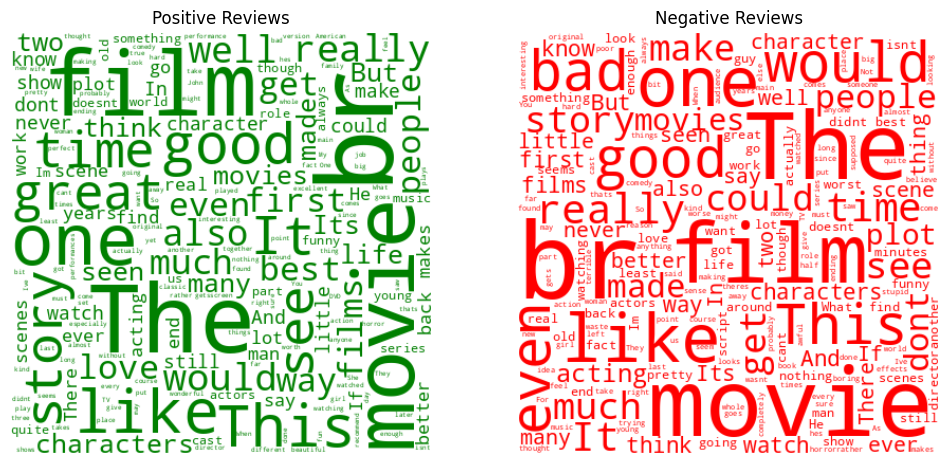

In [ ]:
def generate_wordclouds(df):
    '''
    Generate two word clouds from the 50 most frequent words in the list of positive and negative reviews respectively.

    '''
    stop_words = set(stopwords.words('english'))

    # Separating reviews by sentiment
    positive_reviews = df[df['sentiment'] == 'positive']['review']
    negative_reviews = df[df['sentiment'] == 'negative']['review']


    def get_words(reviews):
        all_words = []
        for review in reviews:
            review = re.sub(r"[^\w\s]", '', review)
            review = re.sub(r"\d", '', review)
            words = review.split()
            filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
            all_words.extend(filtered_words)
        return all_words


    positive_words = get_words(positive_reviews)
    negative_words = get_words(negative_reviews)


    positive_counts = Counter(positive_words)
    negative_counts = Counter(negative_words)


    positive_wordcloud = WordCloud(
        width=400,
        height=400,
        max_words=200,
        max_font_size=100,
        background_color='white',
        color_func=lambda *args, **kwargs: "green"
    ).generate_from_frequencies(positive_counts)

    negative_wordcloud = WordCloud(
        width=400,
        height=400,
        max_words=200,
        max_font_size=100,
        background_color='white',
        color_func=lambda *args, **kwargs: "red"
    ).generate_from_frequencies(negative_counts)


    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(positive_wordcloud, interpolation='bilinear')
    plt.title('Positive Reviews')
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(negative_wordcloud, interpolation='bilinear')
    plt.title('Negative Reviews')
    plt.axis("off")
    plt.savefig('word_clouds.jpg', format='jpeg', bbox_inches='tight')
    plt.show()

generate_wordclouds(df)


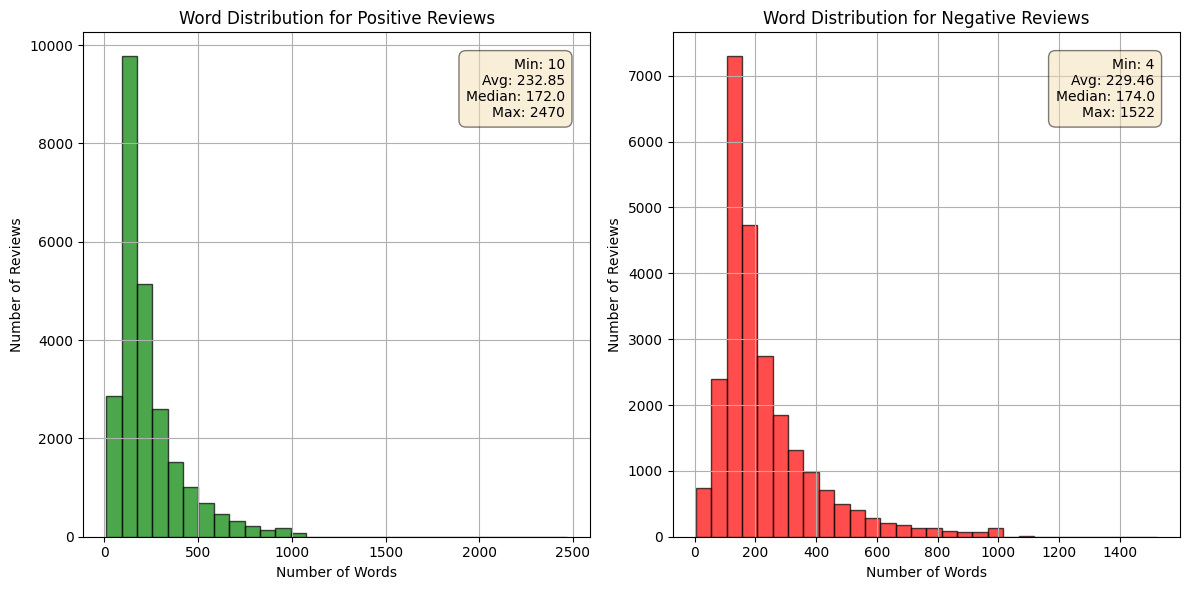

In [ ]:
def plot_review_length_by_sentiment(df):
    '''
    Plots histograms of the number of words per review for positive and negative reviews with summary statistics.

    '''

    positive_reviews = df[df['sentiment'] == 'positive']['review']
    negative_reviews = df[df['sentiment'] == 'negative']['review']


    def get_review_lengths(reviews):
        return [len(review.split()) for review in reviews]


    positive_lengths = get_review_lengths(positive_reviews)
    negative_lengths = get_review_lengths(negative_reviews)


    def get_summary_stats(lengths):
        return {
            'min': np.min(lengths),
            'avg': np.mean(lengths),
            'median': np.median(lengths),
            'max': np.max(lengths)
        }

    pos_stats = get_summary_stats(positive_lengths)
    neg_stats = get_summary_stats(negative_lengths)


    plt.figure(figsize=(12, 6))

    # Plot for positive reviews
    plt.subplot(1, 2, 1)
    plt.hist(positive_lengths, bins=30, color='green', edgecolor='black', alpha=0.7)
    plt.title('Word Distribution for Positive Reviews')
    plt.xlabel('Number of Words')
    plt.ylabel('Number of Reviews')
    plt.grid(True)
    stats_text = f"Min: {pos_stats['min']}\nAvg: {pos_stats['avg']:.2f}\nMedian: {pos_stats['median']}\nMax: {pos_stats['max']}"
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.5", facecolor='wheat', alpha=0.5))

    # Plot for negative reviews
    plt.subplot(1, 2, 2)
    plt.hist(negative_lengths, bins=30, color='red', edgecolor='black', alpha=0.7)
    plt.title('Word Distribution for Negative Reviews')
    plt.xlabel('Number of Words')
    plt.ylabel('Number of Reviews')
    plt.grid(True)
    stats_text = f"Min: {neg_stats['min']}\nAvg: {neg_stats['avg']:.2f}\nMedian: {neg_stats['median']}\nMax: {neg_stats['max']}"
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.5", facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig('review_length.jpg', format='jpeg', bbox_inches='tight')
    plt.show()

plot_review_length_by_sentiment(df)


---

## 📊 감성별 리뷰 길이 분포 분석 요약

이 스크립트는 각 리뷰를 단어 단위로 분절하여 길이를 측정하고, 이를 히스토그램과 기초 통계량으로 시각화하여 데이터의 특성을 파악합니다.

### 1. 데이터 수치화 흐름 (Data Quantification)
* **단어 수 계산 (`get_review_lengths`):** 각 리뷰 문자열을 `split()`하여 단어 리스트로 만든 뒤, 그 리스트의 길이를 반환합니다.
* **통계량 산출 (`get_summary_stats`):** `numpy`를 활용하여 각 그룹(긍정/부정)의 **최솟값, 평균, 중앙값, 최댓값**을 계산합니다.

### 2. 시각화 전략 (Visualization)
* **히스토그램(Histogram):** 단어 수의 빈도 분포를 보여주기 위해 30개의 구간(`bins=30`)으로 나누어 시각화했습니다.
    * **긍정 리뷰:** 초록색(`green`) 계열로 표시
    * **부정 리뷰:** 빨간색(`red`) 계열로 표시
* **통계 박스(Summary Box):** 그래프 우측 상단에 텍스트 박스를 배치하여 주요 지표(평균, 중앙값 등)를 차트 안에서 즉시 확인할 수 있도록 설계되었습니다.

---

## 🔍 분석 기술 구성표

| 단계 | 라이브러리/함수 | 주요 역할 |
| :--- | :--- | :--- |
| **Tokenizing** | `split()` | 텍스트를 공백 기준으로 분리하여 단어 수 측정 |
| **Statistics** | `numpy` (`np.mean`, `np.median`) | 데이터의 중심 경향성 및 변동성 계산 |
| **Plotting** | `plt.hist()` | 데이터의 분포 형태(왜도, 집중도) 시각화 |
| **Annotation** | `plt.text()` | 그래프 내부에 기초 통계량 수치 삽입 |
| **Output** | `plt.savefig()` | 분석 결과를 `review_length.jpg` 파일로 저장 |

---

## 💡 개념 요약 (Concept Flow)

1.  **샘플링:** 감성 라벨(`sentiment`)에 따라 데이터프레임을 두 그룹으로 나눕니다.
2.  **측정:** 각 그룹 내 개별 리뷰의 단어 개수를 리스트 형태로 추출합니다.
3.  **요약:** 추출된 수치 데이터에서 기술 통계(Descriptive Statistics) 값을 도출합니다.
4.  **비교:** 두 히스토그램을 나란히 배치하여, 특정 감성에서 리뷰가 더 길게 나타나는지 또는 특정 구간에 몰려 있는지 등의 **패턴**을 분석합니다.



---

## 📈 리뷰 길이 분포 분석 결과 (Word Distribution Analysis)

전반적으로 긍정 리뷰와 부정 리뷰의 단어 수 분포는 **오른쪽으로 꼬리가 긴 형태(Right-skewed)**를 보이며, 두 그룹 간의 통계적 수치는 매우 유사한 양상을 띱니다.

### 1. 주요 통계 지표 분석

| 지표 | 긍정 리뷰 (Green) | 부정 리뷰 (Red) | 비교 및 해석 |
| :--- | :---: | :---: | :--- |
| **평균 (Avg)** | **232.85** | **229.46** | 두 그룹 모두 약 230단어 내외로 비슷한 수준입니다. |
| **중앙값 (Median)** | **172.0** | **174.0** | 평균보다 낮으므로, 일부 매우 긴 리뷰가 평균을 높이고 있습니다. |
| **최댓값 (Max)** | **2470** | **1522** | **긍정 리뷰**에서 압도적으로 긴(2400단어 이상) 리뷰가 발견됩니다. |
| **최솟값 (Min)** | 10 | 4 | 부정 리뷰에 아주 짧은 단답형 리뷰가 더 포함되어 있습니다. |

---

### 2. 분포의 특징 (Key Findings)

* **집중 구간 (Mode):** 두 그룹 모두 **100~300단어** 사이의 리뷰가 가장 많이 분포되어 있습니다. 이는 사용자들이 감정과 상관없이 통상적으로 작성하는 리뷰의 길이를 나타냅니다.
* **왜도 (Skewness):** 평균이 중앙값보다 큰 수치를 보이는 것으로 보아, 대다수의 리뷰는 짧지만 극소수의 매우 긴 리뷰들이 존재함을 알 수 있습니다.
* **감성별 차이:** * 긍정 리뷰는 부정 리뷰보다 **극단적으로 긴 리뷰(Outliers)**가 더 많습니다(Max 2470). 만족도가 매우 높을 때 경험을 상세히 서술하는 경향이 있을 수 있습니다.
    * 부정 리뷰는 분포의 정점이 조금 더 완만하며, 긍정 리뷰에 비해 짧은 리뷰의 빈도가 상대적으로 높습니다.

---

### 3. 데이터 분석적 시사점 (Insight)

1.  **모델 학습 시 고려사항:** 리뷰 길이의 편차가 매우 크기 때문에(4단어 ~ 2470단어), 딥러닝 모델(RNN, LSTM 등) 학습 시 `max_length`를 적절히 설정(예: 500~800단어)하여 데이터 손실을 최소화하면서 연산 효율을 높이는 **Padding/Truncating** 전략이 필요합니다.
2.  **비즈니스 인사이트:** 긍정 리뷰의 최댓값이 훨씬 높다는 점은, 충성 고객이 브랜드에 대해 전달하고 싶은 이야기가 더 많음을 시사합니다. 이러한 '장문 리뷰'를 별도로 추출하여 정성적 분석을 진행하면 깊이 있는 인사이트를 얻을 수 있습니다.
3.  **데이터 균일성:** 두 그룹의 평균과 중앙값이 매우 유사하므로, **"리뷰의 길이만으로는 감성을 예측하기 어렵다"**는 결론을 내릴 수 있습니다. 따라서 단어의 빈도나 맥락(Context)을 파악하는 NLP 모델의 역할이 중요해집니다.

---


In [ ]:
def preprocess_review(review):
    '''
    Cleaning of the review: remove non-alphanumeric characters, collapse whitespace, and remove digits.
    '''
    review = re.sub(r"[^\w\s]", ' ', review)  # Replace non-word characters with space
    review = re.sub(r"\s+", ' ', review)      # Replace multiple spaces with a single space
    review = re.sub(r"\d", '', review)        # Remove digits
    return review.strip().lower()

def tokenize_reviews(x_train, x_val, x_test):
    stop_words = set(stopwords.words('english'))

    # tokenize and clean list of reviews
    def tokenize_and_filter(reviews):
        word_list = []
        for review in reviews:
            words = word_tokenize(preprocess_review(review))
            filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
            word_list.extend(filtered_words)
        return word_list

    # Create a corpus
    corpus = Counter(tokenize_and_filter(x_train))
    # Select the 1000 most common words
    vocab = {word: i+1 for i, word in enumerate([word for word, freq in corpus.most_common(1000)])}

    # convert reviews into sequences of indices
    def vectorize_reviews(reviews):
        vectorized = []
        for review in reviews:
            tokenized = word_tokenize(preprocess_review(review))
            indexed = [vocab[word] for word in tokenized if word in vocab]
            vectorized.append(indexed)
        return vectorized

    _x_train = vectorize_reviews(x_train)
    _x_val = vectorize_reviews(x_val)
    _x_test = vectorize_reviews(x_test)

    return _x_train, _x_val, _x_test, vocab


x_train, x_val, x_test, vocab = tokenize_reviews(x_train, x_val, x_test)


이 코드는 자연어 처리(NLP) 모델에 데이터를 입력하기 전, 텍스트를 숫자로 변환하는 **벡터화(Vectorization)**의 핵심 파이프라인을 담고 있습니다.

---

## 텍스트 전처리 및 단어 사전(Vocabulary) 생성 흐름

이 과정은 기계가 이해할 수 없는 문자열 데이터를 정해진 규칙에 따라 **정수 인덱스(Integer Index)** 리스트로 변환하는 작업입니다.

### 1. 정규화 및 정제 (Cleaning)
`preprocess_review` 함수를 통해 노이즈를 제거합니다.
* **특수문자 제거:** 알파벳과 숫자, 공백을 제외한 문자를 공백으로 치환합니다.
* **공백 정규화:** 여러 개의 공백(`\s+`)을 하나의 공백으로 축소합니다.
* **숫자 및 소문자화:** 숫자를 삭제하고 모든 문자를 소문자로 통일하여 데이터의 복잡도를 낮춥니다.

### 2. 토큰화 및 필터링 (Tokenizing & Filtering)
* **Word Tokenize:** 문장을 단어 단위로 쪼갭니다.
* **불용어 제거:** 의미가 적은 조사/접속사(`stop_words`)를 제외합니다.
* **길이 제한:** 길이가 1인 단어(의미가 모호한 단어)를 제거하여 핵심 키워드만 남깁니다.

### 3. 단어 사전 구축 (Vocabulary Building)

* **빈도 기반 선별:** 훈련 데이터(`x_train`)에서 가장 많이 등장한 **상위 1,000개 단어**만 선택합니다.
* **인덱스 할당:** 선택된 단어들에 `1`부터 `1000`까지 고유한 정수 번호를 부여합니다. (이 번호가 해당 단어의 주소가 됩니다.)

### 4. 벡터화 (Vectorization)
* 각 리뷰의 단어들을 단어 사전(`vocab`)에서 찾아 해당 인덱스로 교체합니다.
* **사전에 없는 단어(OOV):** 상위 1,000개에 포함되지 않은 단어는 무시되거나 제외됩니다. 결과적으로 문장은 `[42, 105, 7, ...]`와 같은 정수 리스트가 됩니다.

---

## 핵심 처리 기술 요약표

| 단계 | 적용 함수/라이브러리 | 목적 |
| :--- | :--- | :--- |
| **정규화** | `re.sub()` | 데이터 노이즈 제거 및 통일성 확보 |
| **토큰화** | `word_tokenize()` | 연속된 텍스트를 최소 의미 단위(Token)로 분리 |
| **빈도 분석** | `Counter.most_common(1000)` | 학습에 유의미한 핵심 단어 집합 정의 |
| **인코딩** | `Dictionary Mapping` | 문자를 컴퓨터가 연산 가능한 **정수(Index)**로 변환 |

---

### 💡 데이터 분석적 시사점
이 코드를 거치면 모델은 더 이상 "I love this movie"라는 글자를 보지 않고 `[5, 12, 102]` 같은 숫자를 보게 됩니다.

* **주의점:** 훈련 데이터(`x_train`)로만 사전을 만들고 이를 검증(`x_val`)과 테스트(`x_test`) 세트에 동일하게 적용하는 것이 중요합니다. 테스트 데이터에만 있는 단어를 학습에 사용하면 **데이터 누수(Data Leakage)**가 발생할 수 있기 때문입니다.
* **확장성:** 현재는 상위 1,000개 단어만 사용하므로, 데이터셋의 규모가 크다면 `vocab`의 크기를 늘려 성능을 개선할 수 있습니다.

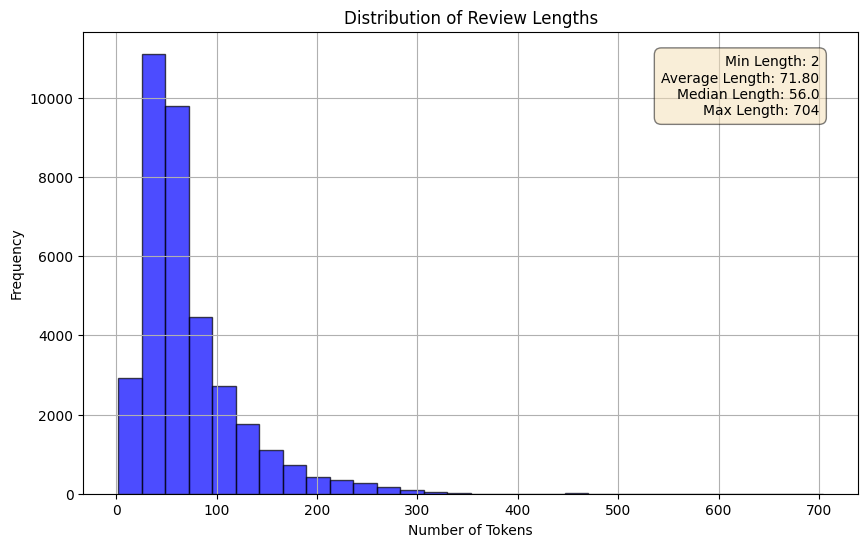

In [ ]:
def plot_review_length_distribution(tokenized_reviews):
    '''
    Plots a histogram of the lengths of tokenized reviews and includes a box with summary statistics.

    '''

    review_lengths = [len(review) for review in tokenized_reviews]

    # Calculate summary statistics
    min_length = np.min(review_lengths)
    avg_length = np.mean(review_lengths)
    median_length = np.median(review_lengths)
    max_length = np.max(review_lengths)


    plt.figure(figsize=(10, 6))
    plt.hist(review_lengths, bins=30, color='blue', edgecolor='black', alpha=0.7)
    plt.title('Distribution of Review Lengths')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Frequency')
    plt.grid(True)


    stats_text = f'Min Length: {min_length}\nAverage Length: {avg_length:.2f}\nMedian Length: {median_length}\nMax Length: {max_length}'
    plt.gca().text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.5", facecolor='wheat', alpha=0.5))
    plt.savefig('review_length_after_tokenization.jpg', format='jpeg', bbox_inches='tight')
    plt.show()

plot_review_length_distribution(x_train)

In [ ]:
def padding_(reviews, max_seq):
    features = np.zeros((len(reviews), max_seq),dtype=int)
    for ii, review in enumerate(reviews):
        if len(review) != 0:
            features[ii, -len(review):] = np.array(review)[:max_seq]
    return np.array(features)

train_data = TensorDataset(torch.from_numpy(padding_(x_train,500)), torch.from_numpy(y_train))
valid_data = TensorDataset(torch.from_numpy(padding_(x_val,500)), torch.from_numpy(y_val))
test_data = TensorDataset(torch.from_numpy(padding_(x_test,500)), torch.from_numpy(y_test))

train_loader = DataLoader(train_data, shuffle=True, batch_size=50)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=50)
test_loader = DataLoader(test_data, shuffle=True, batch_size=50)

이 코드는 정수 인덱스로 변환된 가변 길이의 리뷰 데이터를 동일한 길이로 맞춰주는 **패딩(Padding)** 작업과, 모델 학습을 위해 데이터를 묶어주는 **데이터 로더(DataLoader)** 생성 과정을 담고 있습니다.

---

## 📏 데이터 규격화 및 배치(Batch) 처리 요약

모델(RNN, LSTM 등)은 고정된 크기의 행렬 연산을 수행하기 때문에, 서로 다른 길이의 리뷰들을 일정한 길이로 통일하는 작업이 필수적입니다.

### 1. 제로 패딩 (Zero Padding)
`padding_` 함수는 리뷰 데이터의 길이를 `max_seq`(여기서는 500)로 맞춥니다.
* **공간 생성:** 모든 값이 0으로 채워진 `(리뷰 개수, 500)` 크기의 행렬을 먼저 만듭니다.
* **뒤채우기 (Post-Padding):** `features[ii, -len(review):]` 코드는 리뷰의 내용이 행렬의 **뒷부분**에 위치하도록 합니다. 즉, 문장이 짧으면 앞부분이 0으로 채워집니다.
* **길이 제한:** 만약 리뷰가 500단어보다 길다면 500단어까지만 잘라서 저장합니다.



### 2. 파이토치 데이터셋 구성 (TensorDataset)
* 넘파이(NumPy) 배열로 변환된 패딩 데이터를 파이토치 텐서(`torch.from_numpy`)로 변환합니다.
* **피처(X)**와 **라벨(Y)**을 하나의 쌍으로 묶어 `TensorDataset`으로 만듭니다. 이제 인덱스 하나로 "패딩된 리뷰"와 "긍부정 정답"을 동시에 불러올 수 있습니다.

### 3. 데이터 로더 (DataLoader)
학습 효율을 높이기 위해 데이터를 작은 묶음으로 나누어 공급합니다.
* **Batch Size (50):** 전체 데이터를 한꺼번에 학습하지 않고 50개씩 나누어 처리합니다. 이는 메모리 부담을 줄이고 학습 속도를 높입니다.
* **Shuffle (True):** 학습 시 데이터의 순서를 무작위로 섞어 모델이 특정 순서에 의존하지 않고 보편적인 패턴을 배우도록 합니다.

---

## 🛠 주요 처리 기술 비교표

| 단계 | 주요 도구 | 역할 및 목적 |
| :--- | :--- | :--- |
| **Padding** | `np.zeros` | 가변 길이의 문장을 고정 길이(500) 행렬로 변환 |
| **Mapping** | `TensorDataset` | 입력 데이터(X)와 정답 라벨(Y)을 1:1 대응 셋으로 결합 |
| **Batching** | `DataLoader` | 데이터를 설정된 크기(50)로 묶어서 모델에 공급 |
| **Randomness** | `shuffle=True` | 데이터 순서를 섞어 학습의 편향(Bias) 방지 |

---

### 💡 개념 흐름 (Concept Flow)

1.  **규격화:** 제각각인 리뷰 길이를 500칸짜리 서랍에 넣습니다. 남는 칸은 0으로 채웁니다.
2.  **포장:** 서랍 하나(리뷰)와 이름표(라벨)를 한 세트로 묶습니다.
3.  **배송:** 모델이라는 공장에 한 번에 50세트씩 무작위로 실어 보냅니다.



In [ ]:
class SentimentRNN(nn.Module):
    def __init__(self, no_layers, vocab_size, hidden_dim, embedding_dim, drop_prob=0.5):
        super(SentimentRNN, self).__init__()

        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.no_layers = no_layers
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.GRU(input_size=embedding_dim, hidden_size=self.hidden_dim,
                          num_layers=no_layers, batch_first=True)
        self.dropout = nn.Dropout(drop_prob)
        self.fc = nn.Linear(self.hidden_dim, output_dim)
        self.sig = nn.Sigmoid()

    def forward(self, x, hidden):
        batch_size = x.size(0)
        embeds = self.embedding(x)
        rnn_out, hidden = self.rnn(embeds, hidden)
        rnn_out = rnn_out.contiguous().view(-1, self.hidden_dim)
        out = self.dropout(rnn_out)
        sig_out = self.sig(out)
        sig_out = sig_out.view(batch_size, -1)
        sig_out = sig_out[:, -1]
        return sig_out, hidden

    def init_hidden(self, batch_size):
        ''' Initializes hidden state '''

        h0 = torch.zeros((self.no_layers, batch_size, self.hidden_dim)).to(device)
        return h0

# Hyperparameters
no_layers = 3
vocab_size = len(vocab) + 1
embedding_dim = 300
output_dim = 1
hidden_dim = 256

# Initialize the model
model = SentimentRNN(no_layers, vocab_size, hidden_dim, embedding_dim, drop_prob=0.5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(model)


SentimentRNN(
  (embedding): Embedding(1001, 300)
  (rnn): GRU(300, 256, num_layers=3, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sig): Sigmoid()
)


이 코드는 앞서 준비한 정수 인덱스 데이터를 입력받아 감성을 예측하는 **순환 신경망(RNN) 기반의 딥러닝 모델** 정의부입니다. 클래스 내부에 선언된 각 레이어의 역할과 데이터가 흐르는 과정.

---

## 🏗️ SentimentRNN 모델 구조 요약

이 모델은 단어의 의미를 파악하는 **Embedding**, 시간적 흐름을 학습하는 **GRU**, 그리고 최종 분류를 위한 **Linear** 레이어로 구성되어 있습니다.

### 1. 주요 레이어 구성 (`__init__`)

* **Embedding Layer:** 정수 인덱스를 고차원의 밀집 벡터(`embedding_dim=300`)로 변환합니다. 단어 간의 유사도를 학습하는 단계입니다.
* **GRU Layer:** 일반 RNN보다 성능이 개선된 게이트 유닛을 사용합니다. `num_layers=3`으로 설정되어 깊은 시계열 특징을 추출합니다.
* **Dropout:** 과적합(Overfitting)을 방지하기 위해 학습 중 일부 노드를 무작위로 끕니다(`drop_prob=0.5`).
* **Fully Connected (FC) & Sigmoid:** GRU의 출력값을 바탕으로 0과 1 사이의 확률값(감성 점수)을 출력합니다.

### 2. 순전파 흐름 (`forward`)
1.  **Embedding:** 입력 텐서 `x`를 벡터 뭉치로 바꿉니다.
2.  **GRU 연산:** 시퀀스 데이터를 순차적으로 처리하여 은닉 상태(`hidden`)를 갱신합니다.
3.  **Output Selection:** `sig_out[:, -1]` 코드를 통해 **문장의 맨 마지막 시점(Last Time Step)**의 출력값만 선택합니다. 이는 문장 전체의 맥락이 함축된 최종 결과물입니다.
4.  **Activation:** 시그모이드 함수를 통과시켜 최종적으로 0(부정) 또는 1(긍정)에 가까운 값을 반환합니다.

---

## ⚙️ 설정된 하이퍼파라미터 (Hyperparameters)

| 파라미터 | 설정값 | 의미 |
| :--- | :---: | :--- |
| **no_layers** | 3 | GRU를 3층으로 쌓아 복잡한 패턴 학습 |
| **vocab_size** | len(vocab) + 1 | 사전 크기 + 1(패딩용 0번 인덱스 포함) |
| **embedding_dim** | 300 | 각 단어를 300차원의 공간에 배치 |
| **hidden_dim** | 256 | GRU 내부 은닉층의 뉴런 개수 |
| **output_dim** | 1 | 긍정/부정 이진 분류를 위한 단일 출력 |

---

## 🛠️ 기술적 특징 요약표

| 단계 | 적용 기술 | 특징 및 목적 |
| :--- | :--- | :--- |
| **Feature Extraction** | **GRU** (Gated Recurrent Unit) | LSTM 대비 연산 효율이 좋으면서 장기 의존성 해결 |
| **State Management** | `init_hidden` | 각 배치마다 은닉 상태를 0으로 초기화하여 시작 |
| **Dimension Control** | `view(-1, hidden_dim)` | 3차원 RNN 출력을 2차원 FC 레이어 입력으로 변환 |
| **GPU Acceleration** | `.to(device)` | CUDA를 지원할 경우 연산 속도를 비약적으로 향상 |

---

### 💡 데이터 흐름 요약 (Concept Flow)
> **[Input Indices]** → **Embedding** (단어 의미 부여) → **GRU** (문맥 파악) → **Last Hidden State** (문장 요약) → **Sigmoid** (긍/부정 확률 계산)

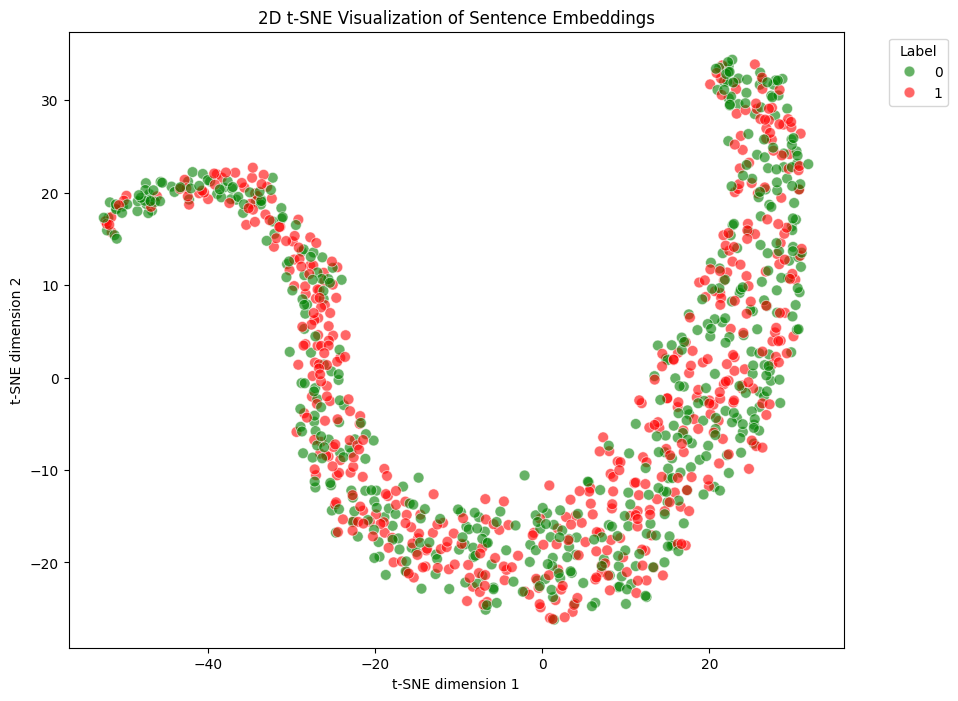

In [ ]:
x_train_tsne = padding_(x_train,500)
x_train_tsne = x_train_tsne[:1000,:]
y_train_tsne= y_train[:1000]

def plot_embeddings(x_train, y_train, model, device, batch_size=50):
    model.eval()
    embeddings_list = []

    # Create a DataLoader to handle the x_train data in batches
    train_dataset = torch.utils.data.TensorDataset(torch.from_numpy(x_train),
                               torch.from_numpy(y_train))
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():  # No need to track gradients
        for x_batch, _ in train_loader:
            x_batch = x_batch.to(device)
            hidden = model.init_hidden(x_batch.size(0))

            # Feed forward through the model to get to the embeddings layer
            embeds = model.embedding(x_batch)
            rnn_out, hidden = model.rnn(embeds, hidden)
            rnn_out = rnn_out.contiguous().view(-1, model.hidden_dim)  # Flatten the output
            out = model.dropout(rnn_out)
            linear_output = model.fc(out)

            embeddings_list.append(linear_output.cpu())  # Store CPU data

    # Concatenate all batch embeddings into a single matrix
    all_embeddings = torch.cat(embeddings_list, dim=0)

    all_embeddings = all_embeddings.view(-1, 500)

    # Reduce dimensions to 2D using t-SNE for visualization
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(all_embeddings.numpy())

    df = pd.DataFrame(data=embeddings_2d, columns=['TSNE-1', 'TSNE-2'])
    df['label'] = y_train
    custom_palette = {0: 'green', 1: 'red'}

    plt.figure(figsize=(10, 8))
    scatter = sns.scatterplot(data=df, x='TSNE-1', y='TSNE-2', hue='label', palette=custom_palette , s=60, alpha=0.6)
    plt.title('2D t-SNE Visualization of Sentence Embeddings')
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc=2)
    plt.savefig('tsne_model_untrained_projection.jpg', format='jpeg', bbox_inches='tight')
    plt.show()


plot_embeddings(x_train_tsne, y_train_tsne, model, device, batch_size=50)


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


lr = 0.001

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

def acc(pred, label):
    """Calculate accuracy by comparing predicted labels with true labels."""
    pred = torch.round(pred.squeeze())
    return torch.sum(pred == label.squeeze()).item()

clip = 5
epochs = 5
valid_loss_min = np.inf


epoch_tr_loss, epoch_vl_loss = [], []
epoch_tr_acc, epoch_vl_acc = [], []


for epoch in range(epochs):
    train_losses = []
    train_acc = 0.0
    model.train()  # Set model to training mode

    # Initialize hidden state
    h = model.init_hidden(50)

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Detach hidden states
        h = h.data

        model.zero_grad()
        output, h = model(inputs, h)

        # Calculate the loss
        loss = criterion(output.squeeze(), labels.float())
        loss.backward()
        train_losses.append(loss.item())

        # Calculate accuracy
        accuracy = acc(output, labels)
        train_acc += accuracy

        # Clip gradients to prevent exploding gradient issues in RNNs
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

    # Validation phase
    val_losses = []
    val_acc = 0.0
    model.eval()  # Set model to evaluation mode
    val_h = model.init_hidden(50)

    for inputs, labels in valid_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Detach hidden states
        val_h = val_h.data

        output, val_h = model(inputs, val_h)
        val_loss = criterion(output.squeeze(), labels.float())

        val_losses.append(val_loss.item())

        accuracy = acc(output, labels)
        val_acc += accuracy

    epoch_train_loss = np.mean(train_losses)
    epoch_val_loss = np.mean(val_losses)
    epoch_train_acc = train_acc / len(train_loader.dataset)
    epoch_val_acc = val_acc / len(valid_loader.dataset)

    epoch_tr_loss.append(epoch_train_loss)
    epoch_vl_loss.append(epoch_val_loss)
    epoch_tr_acc.append(epoch_train_acc)
    epoch_vl_acc.append(epoch_val_acc)

    print(f'Epoch {epoch+1}')
    print(f'Train Loss: {epoch_train_loss} Val Loss: {epoch_val_loss}')
    print(f'Train Accuracy: {epoch_train_acc * 100}% Val Accuracy: {epoch_val_acc * 100}%')
    print(' ')



Epoch 1
Train Loss: 0.5947623892790741 Val Loss: 0.4849901307374239
Train Accuracy: 63.19166666666667% Val Accuracy: 82.92500000000001%
 
Epoch 2
Train Loss: 0.5334407152814997 Val Loss: 0.45267387926578523
Train Accuracy: 67.62777777777778% Val Accuracy: 85.95%
 
Epoch 3
Train Loss: 0.5193157127747933 Val Loss: 0.45082603469491006
Train Accuracy: 68.41666666666667% Val Accuracy: 85.775%
 
Epoch 4
Train Loss: 0.5065054701434242 Val Loss: 0.44792385324835776
Train Accuracy: 69.59166666666667% Val Accuracy: 86.2%
 
Epoch 5
Train Loss: 0.49681940612693626 Val Loss: 0.4487549509853125
Train Accuracy: 70.31111111111112% Val Accuracy: 86.0%
 


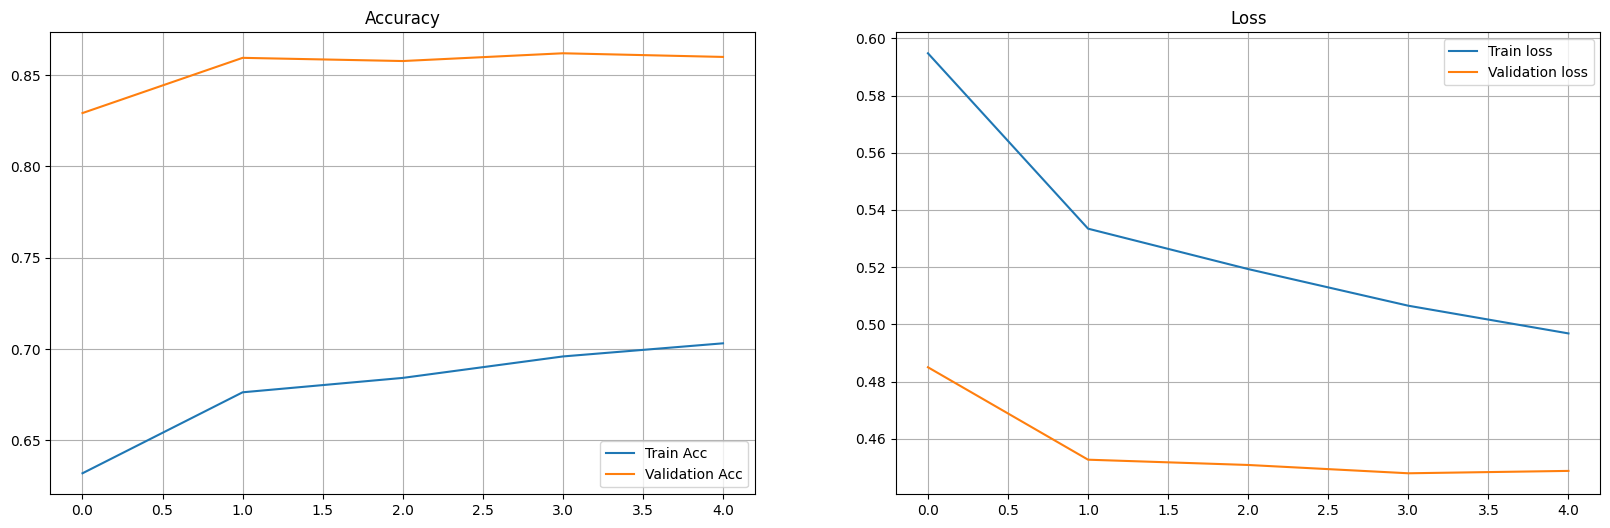

In [ ]:
fig = plt.figure(figsize = (20, 6))
plt.subplot(1, 2, 1)
plt.plot(epoch_tr_acc, label='Train Acc')
plt.plot(epoch_vl_acc, label='Validation Acc')
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epoch_tr_loss, label='Train loss')
plt.plot(epoch_vl_loss, label='Validation loss')
plt.title("Loss")
plt.legend()
plt.grid()
plt.savefig('accuracy_and_loss.jpg', format='jpeg', bbox_inches='tight')
plt.show()

Accuracy on test set: 0.8506


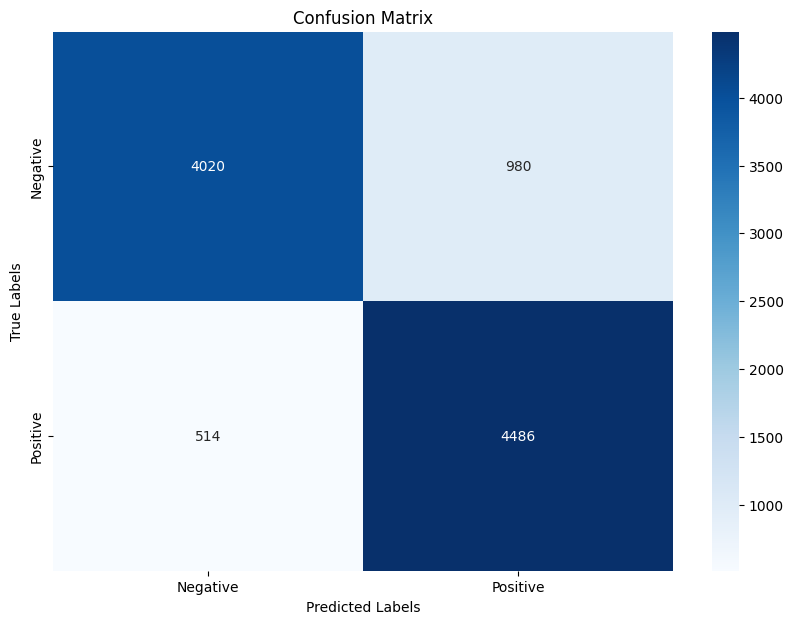

In [ ]:
def predict_batch(model, data_loader, device):
    """Predict output for a batch of data using the RNN model."""
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            batch_size = inputs.size(0)

            hidden = model.init_hidden(batch_size).to(device)

            output, _ = model(inputs, hidden)

            predicted_probs = torch.sigmoid(output)
            predicted_labels = (predicted_probs > 0.60).float()

            predictions.extend(predicted_labels.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return predictions, true_labels, predicted_probs, labels


predictions, true_labels, predicted_probs, labels = predict_batch(model, test_loader, device)
print(f'Accuracy on test set: {accuracy_score(true_labels, predictions)}')
# Plot confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.jpg', format='jpeg', bbox_inches='tight')
plt.show()

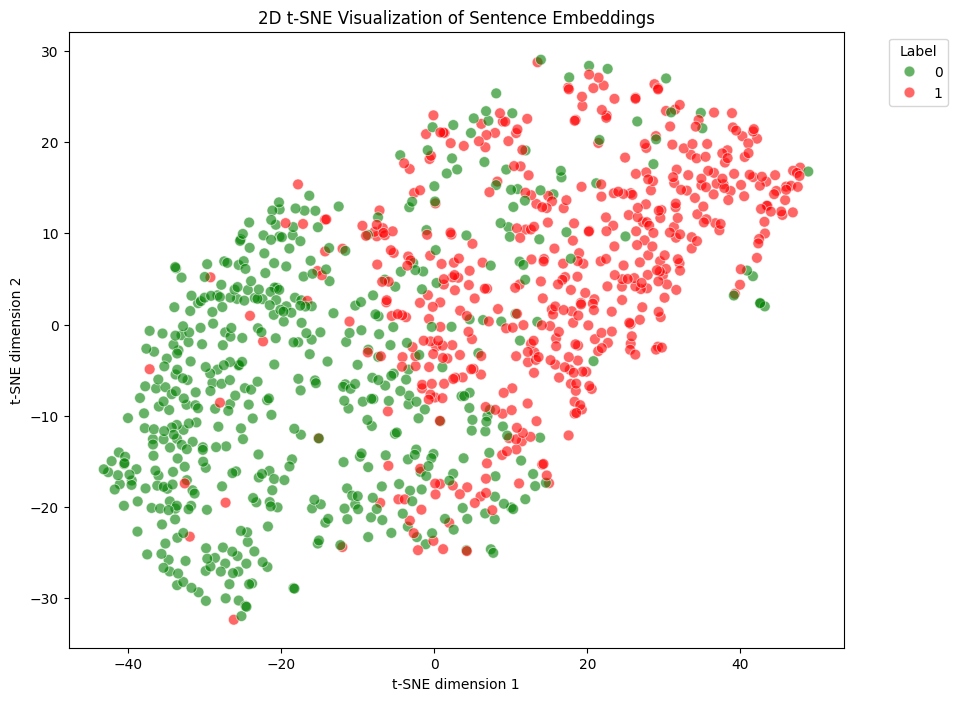

In [ ]:
plot_embeddings(x_train_tsne, y_train_tsne, model, device, batch_size=50)